<a href="https://colab.research.google.com/github/aaqhilahamed2004-ops/QNickel26/blob/main/MvNM_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, partial_trace, entropy, Operator

# ─────────────────────────────────────────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
# Architecture (revised, May 2026):
#   - N_BH qubits: black hole register, starts fully occupied
#   - Radiation register: starts EMPTY, grows by 1 qubit per emission step
#   - No separate ENV register — radiation IS the environment
#   - Emitted qubits accumulate memory via collision-model inter-ancilla
#     interactions (Lorenzo, Ciccarello & Palma 2017) and back-act on BH
#   - Global statevector: fixed 2^N_BH dimension throughout (pure state)
#
# Primary observable: S_BH = von Neumann entropy of BH register
#   - Markovian: S(BH) falls due to Hilbert-space shrinking; S(R) monotonic
#   - Non-Markovian: S(BH) shows Page-curve-like recovery; S(R) peaks+falls
#
# Markovian model: numpy density matrix + depolarising Kraus channel (p=1)
#   - Qubit 0 fully decohered each step: information DESTROYED, not transferred
#   - S(radiation) = cumulative entropy emitted = monotonically increasing
#   - This is the GKSL Lindblad limit in discrete time
#
# Page time = N_BH // 2

N_BH = 10         # black hole size (14 exceeds available RAM for statevector)
C_M  = '#1A6FB5'   # Markovian colour
C_NM = '#E06000'   # Non-Markovian colour

print(f"Setup: N_BH={N_BH}, N_RAD_initial=0, Page time ≈ step {N_BH//2}")
print(f"Radiation register grows from 0 to {N_BH} qubits over evaporation.")

Setup: N_BH=10, N_RAD_initial=0, Page time ≈ step 5
Radiation register grows from 0 to 10 qubits over evaporation.


In [3]:
G0_GLOBAL = np.pi/20

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CIRCUIT BUILDING BLOCKS
# ─────────────────────────────────────────────────────────────────────────────

def scramble_black_hole(qc, bh):
    """
    Fast-scrambler dynamics on BH register.
    Random layered two-qubit gates implement approximate Haar-random unitary
    (unitary k-design at polynomial depth; Harrow & Low 2009, Brandao et al 2016).
    Models the black hole's own chaotic Hamiltonian evolution.
    Black holes are conjectured to be fastest scramblers in nature (Sekino &
    Susskind 2008): t* ~ log(N_BH).

    Gate angles drawn uniformly from [0, 2π] at each layer — this is
    Haar-random in the sense that each layer samples a different random
    unitary. Uniformity is over the gate angles, not the full unitary group;
    k-design convergence follows from the layered structure (Brandao et al).
    """
    LAYERS = 1
    for _ in range(LAYERS):
        for q in bh:
            qc.rx(np.random.uniform(0, 2*np.pi), q)
            qc.ry(np.random.uniform(0, 2*np.pi), q)
            qc.rz(np.random.uniform(0, 2*np.pi), q)
        if len(bh) > 1:
            for i in range(len(bh) - 1):
                qc.cx(bh[i], bh[i+1])
                qc.cz(bh[i], bh[i+1])
            for i in range(0, len(bh)-1, 2):
                qc.swap(bh[i], bh[i+1])
            if len(bh) > 3:
                qc.cx(bh[0], bh[-1])
                qc.cy(bh[1], bh[-2])

def radiation_memory_interaction(qc, rad):
    """
    Inter-ancilla collision on the radiation register A = {A_1,...,A_n}.

    Implements nearest-neighbour V_{A_k, A_{k+1}} interactions, realising
    the composite collision model memory term
        sum_k V_{A_k, A_{k+1}}
    from Lorenzo, Ciccarello & Palma (2017), Phys. Rev. A 96, 032107.
    Gate angles drawn uniformly from [0, 2pi].
    This interaction builds correlations among previously emitted qubits,
    breaking CP-divisibility of the BH dynamical map => non-Markovian.
    """
    if len(rad) < 2:
        return
    for i in range(len(rad) - 1):
        qc.cx(rad[i], rad[i+1])
        qc.cz(rad[i+1], rad[i])
        qc.rx(np.random.uniform(0, 2*np.pi), rad[i])
        qc.ry(np.random.uniform(0, 2*np.pi), rad[i+1])
        qc.rz(np.random.uniform(0, 2*np.pi), rad[i])

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# BH-RADIATION BACK-ACTION
# ─────────────────────────────────────────────────────────────────────────────
def bh_radiation_backaction(qc, bh, rad, t=None, N_BH_total=None, g0=G0_GLOBAL):
    """
    BH-radiation back-action channel B -> A_{1..n}.

    Coupling ansatz (phenomenological, not derived):
        g(t) = min( g_0 / (1 - t/N_BH),  pi/2 )
    motivated by the Hawking temperature scaling
        T_H(t) proportional to 1/M(t) = 1/[N_BH (1 - t/N_BH)]
    for a Schwarzschild BH with mass M(t) = N_BH(1 - t/N_BH).
    g_0 is a free parameter; constraint g_0 <= pi/(2 N_BH) ensures
    the pi/2 cap is never active and T_H-scaling holds throughout.
    Cap at pi/2 avoids rotation-gate periodicity artefacts.

    Exponential decay with radiation index i:
        coupling(t, i) = g(t) * exp(-0.3 * (|rad| - 1 - i))
    models weaker back-action from older (more distant) radiation qubits.

    Parameters
    ----------
    t           : emission step index (1-indexed), int
    N_BH_total  : N_BH, total initial BH qubit count, int
    g_0         : base coupling strength, float (default G0_GLOBAL)
    """
    if t is not None and N_BH_total is not None:
        frac = t / N_BH_total
        if frac >= 1.0:
            frac = 1.0 - 1e-6
        hawking_factor = 1.0 / (1.0 - frac)
        base_angle = min(g0 * hawking_factor, np.pi / 2)
    else:
        base_angle = g0

    for b in bh:
        for i, r in enumerate(rad):
            coupling = base_angle * np.exp(-0.3 * (len(rad) - 1 - i))
            qc.cz(b, r)
            qc.cx(r, b)
            qc.rx(coupling, b)
            qc.ry(coupling, r)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# KRYLOV SPREAD COMPLEXITY
# Trajectory-based Gram-Schmidt adaptation (no Hamiltonian)
# ─────────────────────────────────────────────────────────────────────────────
_krylov_basis = []

def _reset_krylov():
    global _krylov_basis
    _krylov_basis = []

def compute_spread_complexity(state_history):
    """
    Circuit-native Krylov spread complexity.
    Standard spread complexity (Balasubramanian et al 2022) requires a
    Hamiltonian to generate the Krylov basis via Lanczos recursion.
    Since this model is purely gate-based (no explicit Hamiltonian), we adapt:
    the Krylov basis {|K_n>} is built by incremental Gram-Schmidt
    orthogonalisation of the evolved statevector trajectory {|psi(t)>}.
    Spread complexity: C_K(t) = sum_n n |<K_n|psi(t)>|^2.
    Global statevector is fixed dimension 2^N_BH throughout — inner products
    are always well-defined.
    """
    global _krylov_basis
    for state in state_history[len(_krylov_basis):]:
        vec = np.array(state.data, dtype=complex).flatten()
        norm = np.linalg.norm(vec)
        vec = vec / norm if norm > 1e-12 else vec
        for b in _krylov_basis:
            vec -= np.vdot(b, vec) * b
        norm = np.linalg.norm(vec)
        if norm > 1e-10:
            _krylov_basis.append(vec / norm)
    complexities = []
    for state in state_history:
        # Use the FULL normalised statevector — NOT the Gram-Schmidt residual.
        # The residual from the basis-building loop above is discarded here.
        psi = np.array(state.data, dtype=complex).flatten()
        norm = np.linalg.norm(psi)
        psi = psi / norm if norm > 1e-12 else psi
        C_K_t = sum(n * abs(np.vdot(K_n, psi))**2
                    for n, K_n in enumerate(_krylov_basis))
        complexities.append(C_K_t)
    return complexities

In [7]:
import numpy as np
from qiskit.quantum_info import DensityMatrix, partial_trace, entropy, Operator, Kraus
from qiskit import QuantumCircuit, QuantumRegister
# from qiskit.circuit.library import DepolarizingChannel # Removed in favor of local Kraus definition

# ─────────────────────────────────────────────────
# MARKOVIAN EVAPORATION — DEPOLARISING KRAUS CHANNEL
# ─────────────────────────────────────────────────
# Physical content of Markovianity:
#   At each step, BH qubit 0 is subjected to a fully depolarising channel
#   (p=1). Kraus operators: { I/sqrt(4), X/sqrt(4), Y/sqrt(4), Z/sqrt(4) }.
#   Net effect: qubit 0 decohered to the maximally mixed state I/2,
#   all entanglement with it destroyed — information is destroyed, not
#   transferred. This is the GKSL Lindblad limit in discrete time:
#   a memoryless, CP-divisible map (Breuer, Laine & Piilo 2009).
#
#   The global state rho(t) is a MIXED density matrix (Kraus channel is
#   non-unitary), so S_global > 0. This means S_BH != S_R in general,
#   and I(R:BH) = S_BH + S_R - S_global is well-defined and finite.
#
#   The full joint density matrix rho(t) on all N_BH qubits is maintained
#   throughout, so S_R = S(rho_A) via partial trace over BH at each step —
#   the genuine radiation subsystem entropy, directly comparable to S_R
#   from run_non_markovian_evaporation().
#
#   S_{R,cumul} = sum of per-step emitted entropies is also tracked as a
#   separate observable: it quantifies the total information radiated and
#   is monotonically increasing by construction.
# ─────────────────────────────────────────────────

def vn_entropy_np(rho, base=2):
    ev = np.linalg.eigvalsh(rho.data) # Use .data for DensityMatrix
    ev = ev[ev > 1e-12]
    return float(-np.sum(ev * np.log2(ev))) if base == 2 else float(-np.sum(ev * np.log(ev)))

def run_markovian_evaporation():
    """
    Markovian BH evaporation — depolarising Kraus channel (p=1).

    State: Qiskit DensityMatrix rho(t) on all N_BH qubits (joint BH+Rad).
    Scramble unitary from Qiskit Operator; Kraus channel applied in-place.

    Observables at each step:
      S_BH          : vN entropy of rho_B = Tr_A[rho]   (BH subsystem)
      S_R           : vN entropy of rho_A = Tr_B[rho]   (radiation subsystem,
                      genuine partial trace — comparable to NM S_R)
      S_global      : vN entropy of full rho(t)          (> 0, mixed state)
      I(R:BH)       : S_BH + S_R - S_global             (well-defined, finite)
      S_{R,cumul}   : cumulative sum of per-step emitted entropies
                      (monotonically increasing; measures total info radiated)
    """
    print("Starting Markovian evaporation  [Kraus channel p=1 | CP-divisible]...")
    np.random.seed(42)

    qr = QuantumRegister(N_BH) # A fixed register of N_BH qubits
    qc = QuantumCircuit(qr)

    # Initial state: |0...0> density matrix
    rho = DensityMatrix.from_label('0' * N_BH)

    # Track BH and Radiation qubits by their indices in the global register
    bh_indices  = list(range(N_BH))
    rad_indices = []

    # Kraus operators for depolarizing channel on a single qubit
    # (These are the components for p=1, where each Kraus operator has coefficient 1/2)
    I2 = np.array([[1,0],[0,1]], dtype=complex)
    X  = np.array([[0,1],[1,0]], dtype=complex)
    Y  = np.array([[0,-1j],[1j,0]], dtype=complex)
    Z  = np.array([[1,0],[0,-1]], dtype=complex)

    ent_bh, ent_rad, ent_rad_cumul, mi, s_global_list, steps = [], [], [], [], [], []
    S_rad_total = 0.0

    for step in range(1, N_BH + 1):
        if not bh_indices:
            break

        # Current qubit to be emitted (always the 'first' BH qubit conceptually)
        qubit_to_emit = bh_indices[0]

        # ── 1. Scramble BH (unitary, acts on current BH qubits) ──
        # Create a sub-circuit for scrambling only the BH part
        bh_sub_qc = QuantumCircuit(len(bh_indices), name='BH_scramble')
        scramble_black_hole(bh_sub_qc, list(range(len(bh_indices))))

        # Map this sub-circuit to the global N_BH circuit
        global_qc_scramble = QuantumCircuit(qr, name='Global_Scramble_BH')
        global_qc_scramble.append(bh_sub_qc.to_gate(), [qr[i] for i in bh_indices])

        rho = rho.evolve(global_qc_scramble)

        # ── 2. Depolarising Kraus on qubit_to_emit ────
        # Define and apply Kraus operators locally for p=1 depolarizing channel
        # Create a list of Qiskit Operator objects for the individual Kraus operators.
        # These are already scaled by 0.5 as intended.
        kraus_operators_list = [
            0.5 * Operator(I2),
            0.5 * Operator(X),
            0.5 * Operator(Y),
            0.5 * Operator(Z)
        ]

        # Explicitly create a Kraus channel object from the list of operators.
        # This ensures that `rho.evolve` receives a `Channel` object.
        depolarizing_channel = Kraus(kraus_operators_list)

        # Apply the channel to the specified qubit.
        rho = rho.evolve(depolarizing_channel, [qubit_to_emit])

        # ── 3. S_emitted: entropy of qubit_to_emit before it's 'removed' ──
        # Trace out everything BUT the qubit_to_emit to get its reduced density matrix
        # Indices to trace out are all qubits EXCEPT qubit_to_emit
        indices_to_trace_out_for_q0 = [i for i in range(N_BH) if i != qubit_to_emit]
        rho_q0 = partial_trace(rho, indices_to_trace_out_for_q0)
        S_emitted = entropy(rho_q0, base=2)
        S_rad_total += S_emitted

        # ── 4. Emit: qubit_to_emit moves from BH to Rad register ──
        # Conceptually, the qubit is now radiation. We don't physically remove it from rho
        # (rho always lives on N_BH qubits), but update the 'ownership' lists.
        bh_indices.pop(0) # Remove from BH
        rad_indices.append(qubit_to_emit) # Add to Rad

        # ── 5. Compute subsystem entropies from joint rho ───────────────────────
        if bh_indices:
            # rho_BH = Tr_Rad[rho]: trace out radiation qubits
            rho_BH = partial_trace(rho, rad_indices)
            S_BH = entropy(rho_BH, base=2)

            # rho_R = Tr_BH[rho]: trace out BH qubits
            rho_R = partial_trace(rho, bh_indices)
            S_R = entropy(rho_R, base=2)

            S_global = entropy(rho, base=2) # Entropy of the full (mixed) state
            I_RBH = max(0.0, S_BH + S_R - S_global) # Mutual information
        else:
            # If BH register is empty, all qubits are radiation
            S_BH = 0.0
            rho_R = rho # All of rho is radiation
            S_R = entropy(rho_R, base=2)
            S_global = entropy(rho, base=2)
            I_RBH = 0.0 # No BH, so no mutual information with it

        ent_bh.append(S_BH)
        ent_rad.append(S_R)
        ent_rad_cumul.append(S_rad_total)
        mi.append(I_RBH)
        s_global_list.append(S_global)
        steps.append(step)

        print(f"[Markovian]     Step {step:2d}/{N_BH} | "
              f"S_BH={S_BH:.4f} | S_R={S_R:.4f} | "
              f"S_global={S_global:.4f} | I(R:BH)={I_RBH:.4f} | "
              f"S_{{R,cumul}}={S_rad_total:.4f}")

    return steps, ent_bh, ent_rad, ent_rad_cumul, mi, s_global_list

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# NON-MARKOVIAN EVAPORATION — COLLISION MODEL
# ─────────────────────────────────────────────────────────────────────────────
# Circuit architecture (fixed N_BH-qubit Hilbert space throughout):
#   BH register  B  = {q_0, ..., q_{n_bh-1}}   shrinks by 1 each step
#   Rad register A  = {q_{n_bh}, ..., q_{N_BH-1}}  grows by 1 each step
#   Radiation = environment; emitted ancillae retained in global state.
#
# Each step applies:
#   (1) U_S  : scrambler on B  (fast-scrambling unitary, see scramble_black_hole)
#   (2) V_AA : inter-ancilla memory on A  (Lorenzo et al. 2017)
#   (3) V_BA : BH-radiation back-action  (Hawking-motivated coupling g(t))
#
# Observables (pure global state throughout):
#   S_BH(t) = S( rho_B(t) )         rho_B = Tr_A |Psi><Psi|
#   S_R(t)  = S( rho_A(t) )         rho_A = Tr_B |Psi><Psi|
#   S_global(t) = S( |Psi><Psi| ) = 0  exactly (unitary circuit)
#     => S_BH = S_R  at all t  (Schmidt decomposition)
#   I(R:BH)(t) = S_R + S_BH - S_global = 2 S_BH(t)
# ─────────────────────────────────────────────────────────────────────────────

def run_non_markovian_evaporation():
    print("Starting Non-Markovian evaporation  [collision model | memory ON]...")
    np.random.seed(42)

    current_state = Statevector.from_label('0' * N_BH)
    bh  = list(range(N_BH))
    rad = []
    ent_bh, ent_rad, mi, s_global, steps, state_history = [], [], [], [], [], []

    for step in range(1, N_BH + 1):
        step_qc = QuantumCircuit(N_BH)

        # (1) Scrambler U_S on B
        if len(bh) > 0:
            scramble_black_hole(step_qc, bh)

        # (2) Inter-ancilla memory V_AA on A
        if len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)

        # (3) Back-action V_BA
        if len(bh) > 0 and len(rad) > 0:
            bh_radiation_backaction(step_qc, bh, rad,
                                    t=step, N_BH_total=N_BH, g0=G0_GLOBAL)

        current_state = current_state.evolve(step_qc)
        state_history.append(current_state)

        emitted = bh.pop(0)
        rad.append(emitted)

        if len(bh) > 0:
            rho_BH     = partial_trace(current_state, rad)
            S_BH       = float(entropy(rho_BH, base=2))
            rho_R      = partial_trace(current_state, bh)
            S_R        = float(entropy(rho_R,  base=2))
            # S_global computed explicitly as numerical purity check.
            # Expected value: ~0 (unitary circuit). Any significant deviation
            # indicates a numerical error in the statevector evolution.
            rho_global = DensityMatrix(current_state)
            S_global   = float(entropy(rho_global, base=2))
            I_RBH      = S_R + S_BH   # exact for pure state
        else:
            S_BH = S_R = S_global = I_RBH = 0.0

        ent_bh.append(S_BH);   ent_rad.append(S_R)
        mi.append(I_RBH);      s_global.append(S_global)
        steps.append(step)

        print(f"[Non-Markovian] Step {step:2d}/{N_BH} | "
              f"S_BH={S_BH:.4f} | S_R={S_R:.4f} | "
              f"S_global={S_global:.6f} | I(R:BH)={I_RBH:.4f}")

    return steps, ent_bh, ent_rad, mi, s_global, state_history

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
s_m,  ebh_m,  erad_m,  erad_cumul_m,  mi_m,  s_global_m              = run_markovian_evaporation()
s_nm, ebh_nm, erad_nm, mi_nm, s_global_nm, states_nm                  = run_non_markovian_evaporation()

dS_bh_m  = np.diff(ebh_m)
dS_bh_nm = np.diff(ebh_nm)

# Krylov complexity — computed here so k_nm is available for all plot cells
_reset_krylov()
c_k_nm = compute_spread_complexity(states_nm)  # C_K(t) — Krylov spread complexity

page_idx  = np.argmax(mi_nm)
page_step = page_idx + 1
print(f"\nPage time (peak I(R:BH)): step {page_step}")

Starting Markovian evaporation  [Kraus channel p=1 | CP-divisible]...
[Markovian]     Step  1/10 | S_BH=0.9266 | S_R=1.0000 | S_global=1.9266 | I(R:BH)=0.0000 | S_{R,cumul}=1.0000
[Markovian]     Step  2/10 | S_BH=1.8895 | S_R=2.0000 | S_global=3.8895 | I(R:BH)=0.0000 | S_{R,cumul}=2.0000
[Markovian]     Step  3/10 | S_BH=2.8611 | S_R=3.0000 | S_global=5.8611 | I(R:BH)=0.0000 | S_{R,cumul}=3.0000
[Markovian]     Step  4/10 | S_BH=3.7343 | S_R=4.0000 | S_global=7.7343 | I(R:BH)=0.0000 | S_{R,cumul}=4.0000
[Markovian]     Step  5/10 | S_BH=4.2061 | S_R=5.0000 | S_global=9.2061 | I(R:BH)=0.0000 | S_{R,cumul}=5.0000
[Markovian]     Step  6/10 | S_BH=3.8260 | S_R=6.0000 | S_global=9.8260 | I(R:BH)=0.0000 | S_{R,cumul}=6.0000
[Markovian]     Step  7/10 | S_BH=2.9545 | S_R=7.0000 | S_global=9.9545 | I(R:BH)=0.0000 | S_{R,cumul}=7.0000
[Markovian]     Step  8/10 | S_BH=1.9879 | S_R=8.0000 | S_global=9.9879 | I(R:BH)=0.0000 | S_{R,cumul}=8.0000
[Markovian]     Step  9/10 | S_BH=0.9947 | S_R=9.0

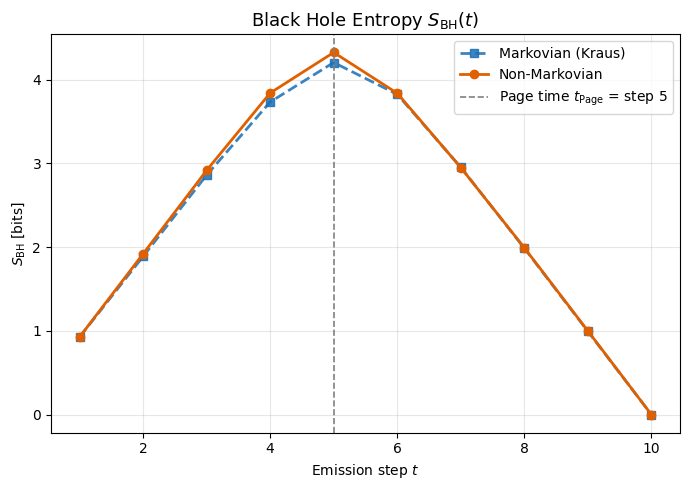

Saved: fig_sbh.pdf


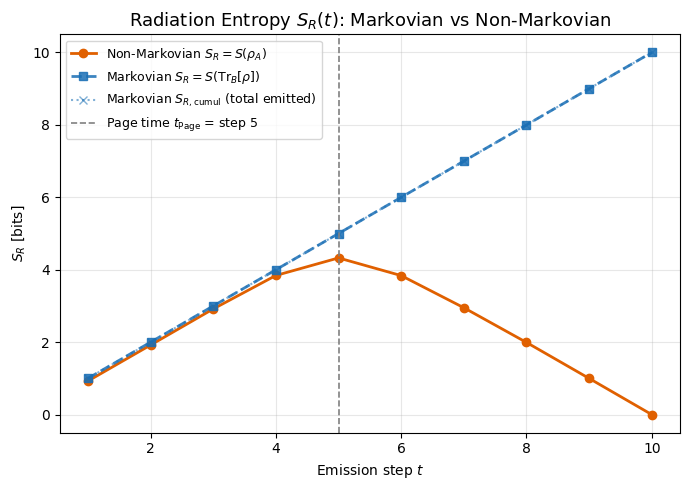

Saved: fig_sr.pdf


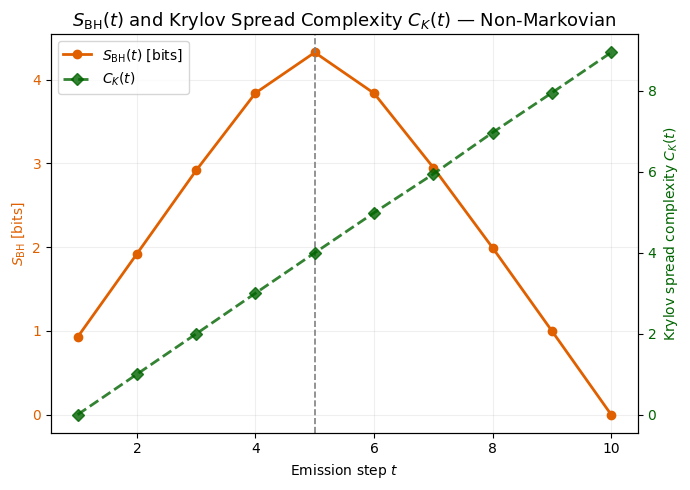

Saved: fig_complexity.pdf


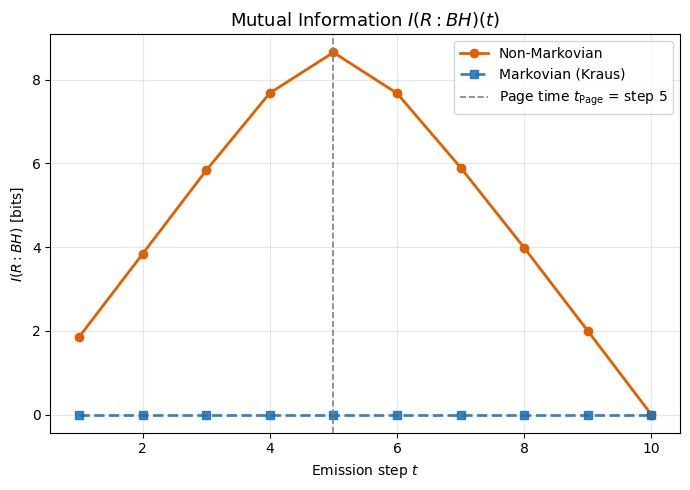

Saved: fig_mi.pdf


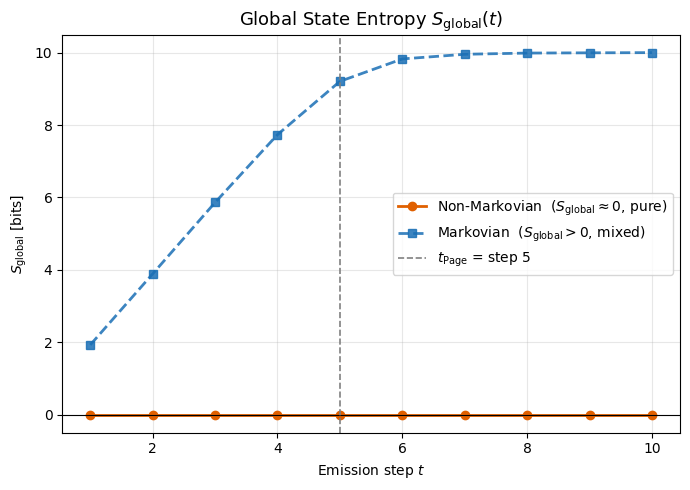

Saved: fig_sglobal.pdf


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# INDIVIDUAL FIGURES
# ─────────────────────────────────────────────────────────────────────────────

# Fig 1: S_BH — Markovian vs Non-Markovian
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_m,  ebh_m,  's--', color=C_M,  lw=2, alpha=0.85, label='Markovian (Kraus)')
ax.plot(s_nm, ebh_nm, 'o-',  color=C_NM, lw=2,             label='Non-Markovian')
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'Page time $t_{{\\rm Page}}$ = step {page_step}')
ax.set_title(r'Black Hole Entropy $S_{\rm BH}(t)$', fontsize=13)
ax.set_xlabel(r'Emission step $t$')
ax.set_ylabel(r'$S_{\rm BH}$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sbh.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_sbh.pdf')

# Fig 2: S_R — genuine subsystem entropy for both models,
#         plus S_{R,cumul} for Markovian as a separate curve
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_nm, erad_nm,      'o-',  color=C_NM,      lw=2,
        label=r'Non-Markovian $S_R = S(\rho_A)$')
ax.plot(s_m,  erad_m,       's--', color=C_M,        lw=2, alpha=0.85,
        label=r'Markovian $S_R = S(\mathrm{Tr}_B[\rho])$')
ax.plot(s_m,  erad_cumul_m, 'x:',  color=C_M,        lw=1.5, alpha=0.55,
        label=r'Markovian $S_{R,\mathrm{cumul}}$ (total emitted)')
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'Page time $t_{{\\rm Page}}$ = step {page_step}')
ax.set_title(r'Radiation Entropy $S_R(t)$: Markovian vs Non-Markovian', fontsize=13)
ax.set_xlabel(r'Emission step $t$')
ax.set_ylabel(r'$S_R$ [bits]')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sr.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_sr.pdf')

# Fig 3: S_BH and K(t) — Non-Markovian (dual axis)
fig, ax_s = plt.subplots(figsize=(7, 5))
ax_k = ax_s.twinx()
l1, = ax_s.plot(s_nm, ebh_nm, 'o-',  color=C_NM,       lw=2,
                label=r'$S_{\rm BH}(t)$ [bits]')
l2, = ax_k.plot(s_nm, c_k_nm, 'D--', color='darkgreen', lw=2, alpha=0.8,
                label=r'$C_K(t)$')
ax_s.axvline(page_step, color='gray', ls='--', lw=1.2,
             label=f'$t_{{\\rm Page}}$ = step {page_step}')
ax_s.set_ylabel(r'$S_{\rm BH}$ [bits]', color=C_NM)
ax_s.tick_params(axis='y', labelcolor=C_NM)
ax_k.set_ylabel(r'Krylov spread complexity $C_K(t)$', color='darkgreen')
ax_k.tick_params(axis='y', labelcolor='darkgreen')
ax_s.legend(handles=[l1, l2], fontsize=10, loc='upper left')
ax_s.set_title(r'$S_{\rm BH}(t)$ and Krylov Spread Complexity $C_K(t)$ — Non-Markovian',
               fontsize=13)
ax_s.set_xlabel(r'Emission step $t$')
ax_s.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('fig_complexity.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_complexity.pdf')

# Fig 4: I(R:BH) — Non-Markovian and Markovian
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_nm, mi_nm, 'o-',  color=C_NM, lw=2,
        label=r'Non-Markovian')
ax.plot(s_m,  mi_m,  's--', color=C_M,  lw=2, alpha=0.85,
        label=r'Markovian (Kraus)')
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'Page time $t_{{\\rm Page}}$ = step {page_step}')
ax.set_title(r'Mutual Information $I(R:BH)(t)$', fontsize=13)
ax.set_xlabel(r'Emission step $t$')
ax.set_ylabel(r'$I(R:BH)$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_mi.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_mi.pdf')

# Fig 5: S_global — verifying purity (NM) vs mixing (Markovian Kraus)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_nm, s_global_nm, 'o-',  color=C_NM, lw=2,
        label=r'Non-Markovian  ($S_{\rm global} \approx 0$, pure)')
ax.plot(s_m,  s_global_m,  's--', color=C_M,  lw=2, alpha=0.85,
        label=r'Markovian  ($S_{\rm global} > 0$, mixed)')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'$t_{{\\rm Page}}$ = step {page_step}')
ax.set_title(r'Global State Entropy $S_{\rm global}(t)$', fontsize=13)
ax.set_xlabel(r'Emission step $t$')
ax.set_ylabel(r'$S_{\rm global}$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sglobal.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_sglobal.pdf')

## BLP Non-Markovianity Measure

**Protocol (Breuer, Laine & Piilo 2009):**
1. Prepare two initial BH states $(\rho_1^{(0)}, \rho_2^{(0)})$ — four probe pairs used below (P1–P4):
   - P1 (non-orthogonal): $|0\rangle^{\otimes N}$ vs $|{+}\rangle|0\rangle^{\otimes (N-1)}$
   - P2 (orthogonal, global flip): $|0\rangle^{\otimes N}$ vs $|1\rangle^{\otimes N}$
   - P3 (orthogonal, single flip): $|0\rangle^{\otimes N}$ vs $|0\cdots01\rangle$
   - P4 (orthogonal, coherent): $|{+}\rangle^{\otimes N}$ vs $|{-}\rangle^{\otimes N}$
2. Evolve both through identical circuit (fixed random seed — isolates memory from randomness)
3. At each step $t$: partial-trace radiation register $\Rightarrow$ reduced BH state $\rho_{\rm BH}(t)$
4. Compute trace distance $D(t) = \frac{1}{2}\|\rho_1(t) - \rho_2(t)\|_1$
5. BLP measure: $\mathcal{N}_{\rm BLP} = \sum_{\{t:\,\sigma(t)>0\}} \Delta D(t)$, where $\sigma(t) = \dot{D}(t)$

$\mathcal{N}_{\rm BLP} > 0 \;\Leftrightarrow\;$ information backflow $\;\Leftrightarrow\;$ non-Markovian dynamics.

In [11]:
# ═════════════════════════════════════════════════════════════════════════════
# BLP NON-MARKOVIANITY MEASURE — DEFINITIONS
# Breuer, Laine & Piilo, PRL 103, 210401 (2009)
#
# N_BH for BLP is set separately from the main evaporation N_BH because
# the BLP trace-distance loop is O(N_BH^2) in circuit depth and O(4^N_BH)
# in density matrix cost. N_BH=10 is the practical ceiling on most hardware.
# All BLP results must state this value explicitly.
# ═════════════════════════════════════════════════════════════════════════════

N_BH_BLP = 10   # BLP-specific system size — stated explicitly in all outputs

def trace_distance(rho1, rho2) -> float:
    """
    D(rho1, rho2) = (1/2) ||rho1 - rho2||_1
    where ||A||_1 = Tr|A| = Tr sqrt(A^dag A) is the trace norm.
    Computed via eigenvalue decomposition of (rho1 - rho2) (Hermitian).
    Exact for finite-dimensional density matrices.
    """
    eigvals = np.linalg.eigvalsh(rho1.data - rho2.data)
    return 0.5 * float(np.sum(np.abs(eigvals)))


def run_evaporation_for_blp(probe: str,
                             seed:      int   = 100,
                             markovian: bool  = False,
                             g0:        float = G0_GLOBAL,
                             n_bh:      int   = None):
    """
    Run one evaporation trajectory and return the reduced BH density matrix
    rho_BH(t) at each emission step via partial trace over the radiation register.

    This function mirrors run_non_markovian_evaporation exactly in circuit
    structure. The markovian=True branch disables radiation_memory_interaction
    and bh_radiation_backaction, leaving only the scrambler — used as the
    causal control to attribute BLP backflow to the memory terms.

    Parameters
    ----------
    probe     : initial BH state label
                'zero'      |0>^{otimes n_bh}
                'plus'      |+>|0>^{otimes(n_bh-1)}
                'ones'      |1>^{otimes n_bh}
                'ones_last' |0...01>  (single-qubit flip)
                'plus_all'  |+>^{otimes n_bh}
                'minus_all' |->^{otimes n_bh}
    seed      : RNG seed. Both probes in a pair must use the same seed so
                gate angles are identical — any difference in D(t) is then
                due to the initial condition alone, isolating the memory effect.
    markovian : if True, memory terms disabled (scrambler-only control).
    g0        : base back-action coupling g_0 for the Hawking-motivated ansatz
                g(t) = min( g_0 / (1 - t/N_{BH}), pi/2 ), T_H-scaling if g_0 <= pi/(2 N_{BH}).
    n_bh      : system size. Defaults to N_BH_BLP if not specified.

    Returns
    -------
    rho_series : list of DensityMatrix, length n_bh
                 rho_series[t] = rho_BH after emission step t+1.
    """
    if n_bh is None:
        n_bh = N_BH_BLP

    np.random.seed(seed)

    label_map = {
        'plus':      '+' + '0' * (n_bh - 1),
        'ones':      '1' * n_bh,
        'ones_last': '0' * (n_bh - 1) + '1',
        'plus_all':  '+' * n_bh,
        'minus_all': '-' * n_bh,
    }
    init_label = label_map.get(probe, '0' * n_bh)

    state = Statevector.from_label(init_label)
    bh, rad, rho_series = list(range(n_bh)), [], []

    step = 0
    while len(bh) > 0:
        step += 1
        step_qc = QuantumCircuit(n_bh)
        scramble_black_hole(step_qc, bh)

        if not markovian:
            if len(rad) >= 2:
                radiation_memory_interaction(step_qc, rad)
            if len(rad) > 0:
                # t=step matches run_non_markovian_evaporation exactly.
                # Earlier versions passed t=len(rad) — off by one, now fixed.
                bh_radiation_backaction(step_qc, bh, rad,
                                        t=step, N_BH_total=n_bh, g0=g0)

        state   = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)

        # Partial trace over radiation to get reduced BH state.
        # At final step bh is empty; return reduced state of last emitted qubit
        # as a placeholder so rho_series length equals n_bh throughout.
        if len(bh) > 0:
            rho_series.append(partial_trace(state, rad))
        else:
            rho_series.append(partial_trace(state, list(range(n_bh - 1))))

    return rho_series


def compute_blp_pair(probe_a, probe_b, seed, g0, markovian=False, n_bh=None):
    """
    Compute trace distance series D(t), increments dD, and N_BLP
    for a single probe pair at a given seed and coupling g0.

    Returns
    -------
    steps  : list[int]
    D_vals : list[float]
    dD     : np.ndarray
    N_BLP  : float
    """
    if n_bh is None:
        n_bh = N_BH_BLP
    s_a = run_evaporation_for_blp(probe_a, seed=seed, markovian=markovian,
                                   g0=g0, n_bh=n_bh)
    s_b = run_evaporation_for_blp(probe_b, seed=seed, markovian=markovian,
                                   g0=g0, n_bh=n_bh)
    T      = min(len(s_a), len(s_b))
    D_vals = [trace_distance(s_a[t], s_b[t]) for t in range(T)]
    steps  = list(range(1, T + 1))
    dD     = np.diff(D_vals)
    N_BLP  = float(np.sum(dD[dD > 0]))
    return steps, D_vals, dD, N_BLP


# Probe pairs — defined once, used by all BLP cells below
PROBE_PAIRS = [
    ('zero',     'plus',      r"$|0\rangle^{\otimes N_BH}$ vs "
                              r"$|{+}\rangle|0\rangle^{\otimes(N-1)}$",
                              "non-orthogonal, $D_0 = 1/\\sqrt{2} \\approx 0.707$",
                              "P1: non-orthogonal"),
    ('zero',     'ones',      r"$|0\rangle^{\otimes N_BH}$ vs "
                              r"$|1\rangle^{\otimes N_BH}$",
                              "orthogonal, $D_0 = 1$",
                              "P2: orthogonal (global flip)"),
    ('zero',     'ones_last', r"$|0\rangle^{\otimes N_BH}$ vs "
                              r"$|0\cdots01\rangle$",
                              "orthogonal, $D_0 = 1$",
                              "P3: orthogonal (single flip)"),
    ('plus_all', 'minus_all', r"$|{+}\rangle^{\otimes N_BH}$ vs "
                              r"$|{-}\rangle^{\otimes N_BH}$",
                              "orthogonal, $D_0 = 1$",
                              "P4: orthogonal (coherent)"),
]

print(f"BLP definitions loaded. N_BH_BLP={N_BH_BLP}, G0_GLOBAL={G0_GLOBAL:.4f}")
print(f"Probe pairs defined: {[p[4] for p in PROBE_PAIRS]}")

BLP definitions loaded. N_BH_BLP=10, G0_GLOBAL=0.1571
Probe pairs defined: ['P1: non-orthogonal', 'P2: orthogonal (global flip)', 'P3: orthogonal (single flip)', 'P4: orthogonal (coherent)']


BLP Primary Run  (N_BH=10, seed=100, g0=0.1571)
─────────────────────────────────────────────────────────────────
  P1: non-orthogonal                   N_BLP = 0.030446  ✓ non-Markovian
  P2: orthogonal (global flip)         N_BLP = 0.000637  ✓ non-Markovian
  P3: orthogonal (single flip)         N_BLP = 0.199761  ✓ non-Markovian
  P4: orthogonal (coherent)            N_BLP = 0.000000  ✗ no backflow

═════════════════════════════════════════════════════════════════
  Pair                                       N̲_BLP  Verdict
  ───────────────────────────────────  ──────────  ────────────────────
  P1: non-orthogonal                     0.030446  ✓ non-Markovian
  P2: orthogonal (global flip)           0.000637  ✓ non-Markovian
  P3: orthogonal (single flip)           0.199761  ✓ non-Markovian
  P4: orthogonal (coherent)              0.000000  ✗ no backflow
═════════════════════════════════════════════════════════════════


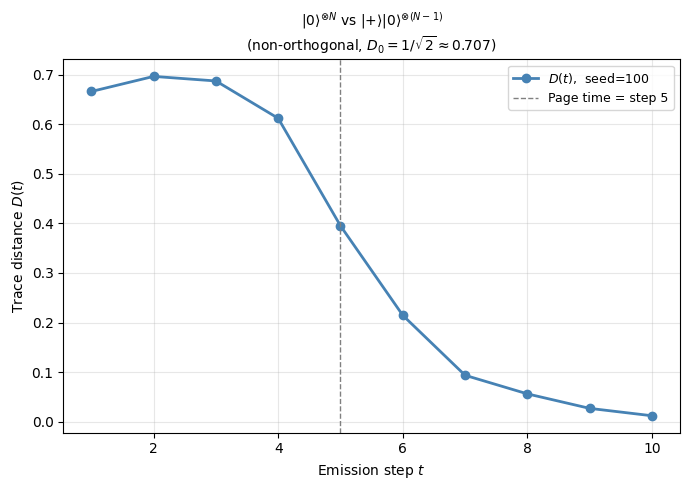

Saved: blp_P1_trace.pdf


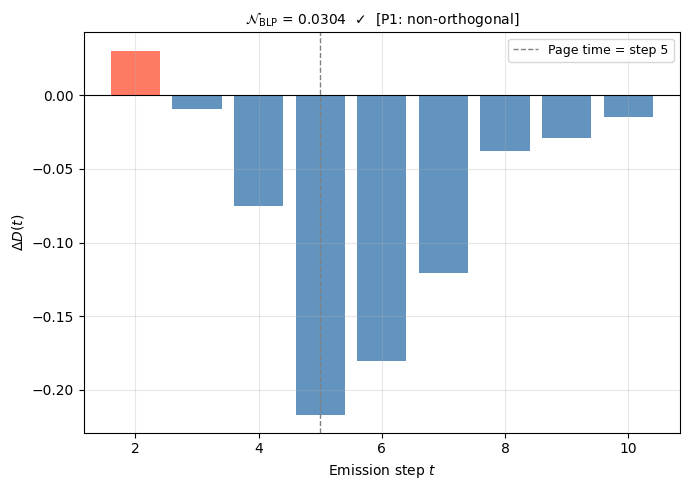

Saved: blp_P1_increments.pdf


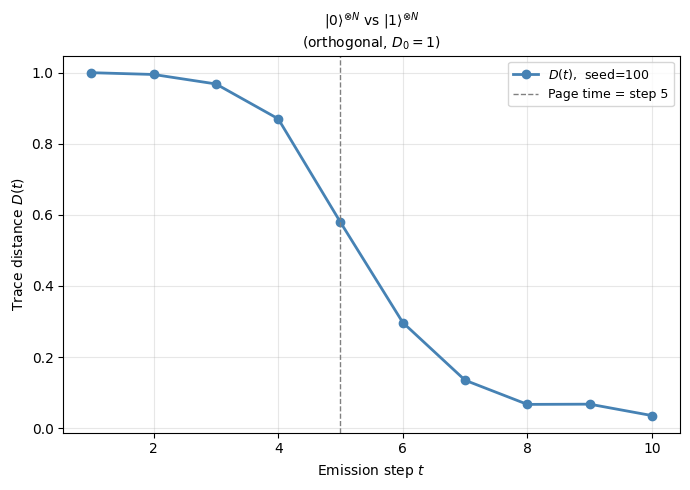

Saved: blp_P2_trace.pdf


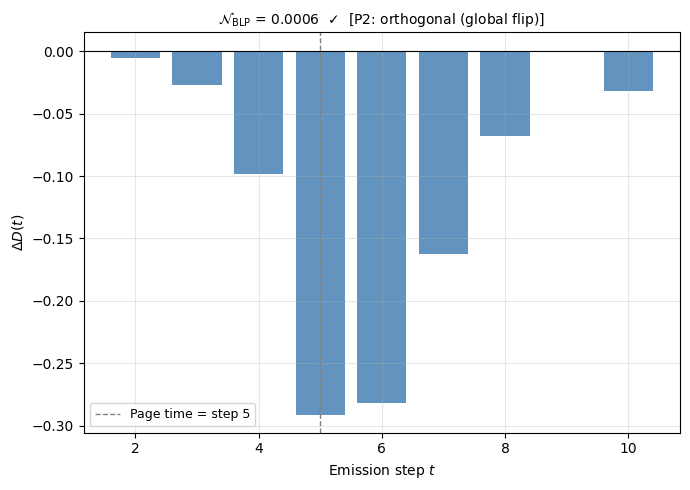

Saved: blp_P2_increments.pdf


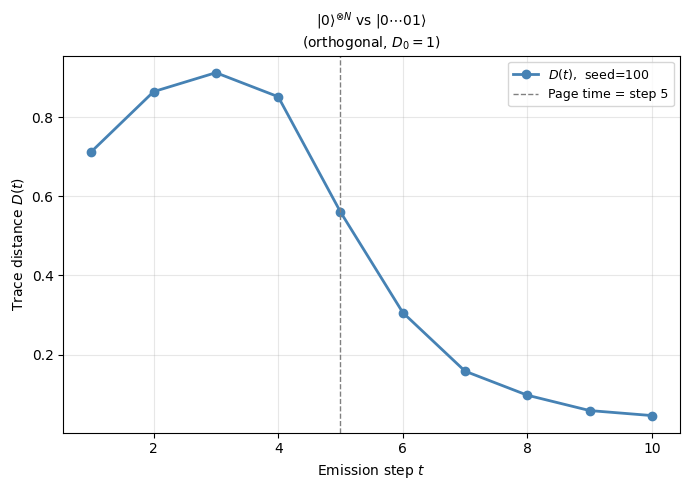

Saved: blp_P3_trace.pdf


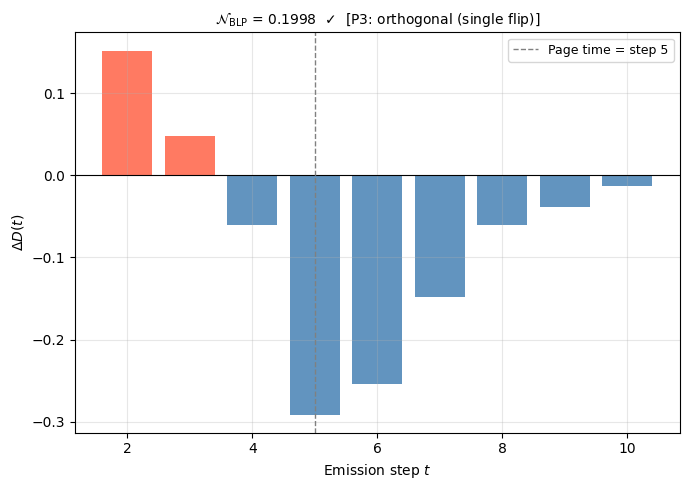

Saved: blp_P3_increments.pdf


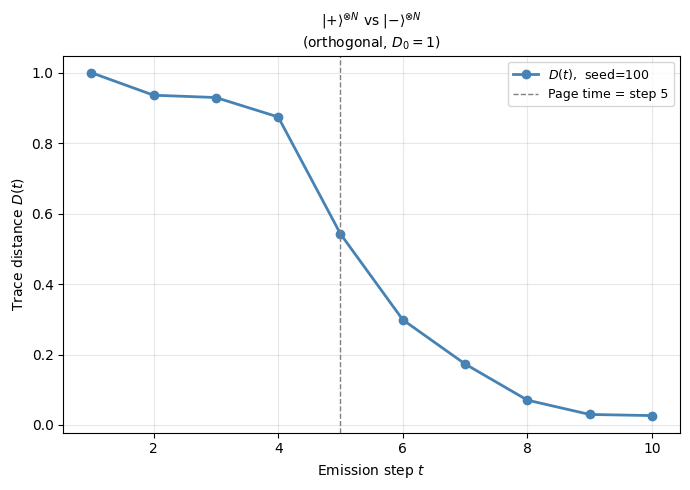

Saved: blp_P4_trace.pdf


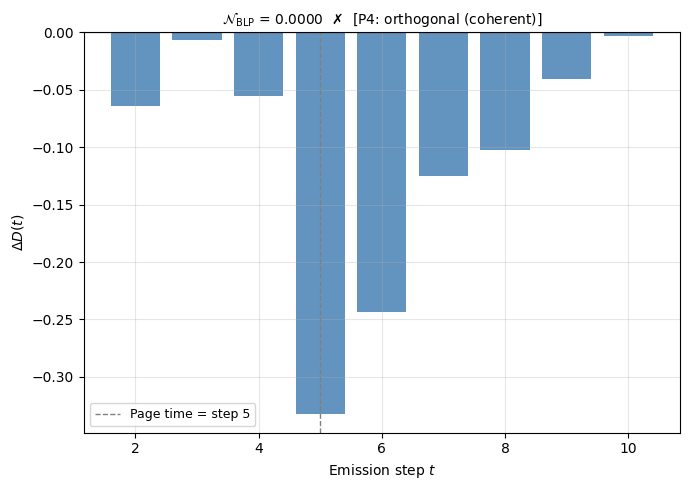

Saved: blp_P4_increments.pdf


In [12]:
# ═════════════════════════════════════════════════════════════════════════════
# BLP PRIMARY RUN — four probe pairs, seed=100, g0=G0_GLOBAL
# ═════════════════════════════════════════════════════════════════════════════

BLP_SEED = 100
BLP_G0   = np.pi/20

print(f"BLP Primary Run  (N_BH={N_BH_BLP}, seed={BLP_SEED}, g0={BLP_G0:.4f})")
print(f"{'─'*65}")

results = []
for pa, pb, tex_label, d0_note, short in PROBE_PAIRS:
    steps, D_vals, dD, N_BLP = compute_blp_pair(pa, pb,
                                                  seed=BLP_SEED,
                                                  g0=BLP_G0)
    results.append((steps, D_vals, dD, N_BLP, tex_label, d0_note, short))
    status = "✓ non-Markovian" if N_BLP > 1e-6 else "✗ no backflow"
    print(f"  {short:<35}  N_BLP = {N_BLP:.6f}  {status}")

print(f"\n{'═'*65}")
print(f"  {'Pair':<35}  {'N̲_BLP':>12}  {'Verdict'}")
print(f"  {'─'*35}  {'─'*10}  {'─'*20}")
for _, _, _, N_BLP, _, _, short in results:
    flag = "✓ non-Markovian" if N_BLP > 1e-6 else "✗ no backflow"
    print(f"  {short:<35}  {N_BLP:>10.6f}  {flag}")
print(f"{'═'*65}")

# ── Plots: one trace-distance + one increment figure per pair ─────────────────
for idx, (steps, D_vals, dD, N_BLP, tex_label, d0_note, short) in enumerate(results):
    pair_tag = f"P{idx+1}"

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(steps, D_vals, 'o-', color='steelblue', lw=2,
            label=f'$D(t)$,  seed={BLP_SEED}')
    ax.axvline(N_BH_BLP // 2, color='gray', ls='--', lw=1,
               label=f'Page time = step {N_BH_BLP // 2}')
    ax.set_xlabel("Emission step $t$")
    ax.set_ylabel("Trace distance $D(t)$")
    ax.set_title(f"{tex_label}\n({d0_note})", fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"blp_{pair_tag}_trace.pdf", bbox_inches='tight', dpi=200)
    plt.show(); print(f"Saved: blp_{pair_tag}_trace.pdf")

    fig, ax = plt.subplots(figsize=(7, 5))
    bar_colors = ['tomato' if d > 0 else 'steelblue' for d in dD]
    ax.bar(steps[1:], dD, color=bar_colors, alpha=0.85)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(N_BH_BLP // 2, color='gray', ls='--', lw=1,
               label=f'Page time = step {N_BH_BLP // 2}')
    ax.set_xlabel("Emission step $t$")
    ax.set_ylabel(r"$\Delta D(t)$")
    ax.set_title(
        r"$\mathcal{N}_{\rm BLP}$" + f" = {N_BLP:.4f}"
        + ("  ✓" if N_BLP > 1e-6 else "  ✗")
        + f"  [{short}]",
        fontsize=10
    )
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"blp_{pair_tag}_increments.pdf", bbox_inches='tight', dpi=200)
    plt.show(); print(f"Saved: blp_{pair_tag}_increments.pdf")

BLP Robustness  (N_BH=10)
Seed sweep : [5, 25, 45, 65, 85, 105, 125, 145, 165, 185, 205, 225, 245, 265, 285, 305, 325, 345, 365, 385, 405, 425, 445, 465, 485, 505, 525, 545, 565, 585, 605, 625, 645, 665, 685, 705, 725, 745, 765, 785, 805, 825, 845, 865, 885, 905, 925, 945, 965, 985, 1005, 1025, 1045, 1065, 1085, 1105, 1125, 1145, 1165, 1185, 1205, 1225, 1245, 1265, 1285, 1305, 1325, 1345, 1365, 1385, 1405, 1425, 1445, 1465, 1485, 1505, 1525, 1545, 1565]
g0 sweep   : ['0.0982', '0.1309', '0.1963', '0.3927', '1.5708', '2.3562']
Fixed seed for g0 sweep : 120
Fixed g0 for seed sweep : 0.1571

── Part 1: Seed sweep ──────────────────────────────────────────────────
Pair                                      5      25      45      65      85     105     125     145     165     185     205     225     245     265     285     305     325     345     365     385     405     425     445     465     485     505     525     545     565     585     605     625     645     665     685     705     725

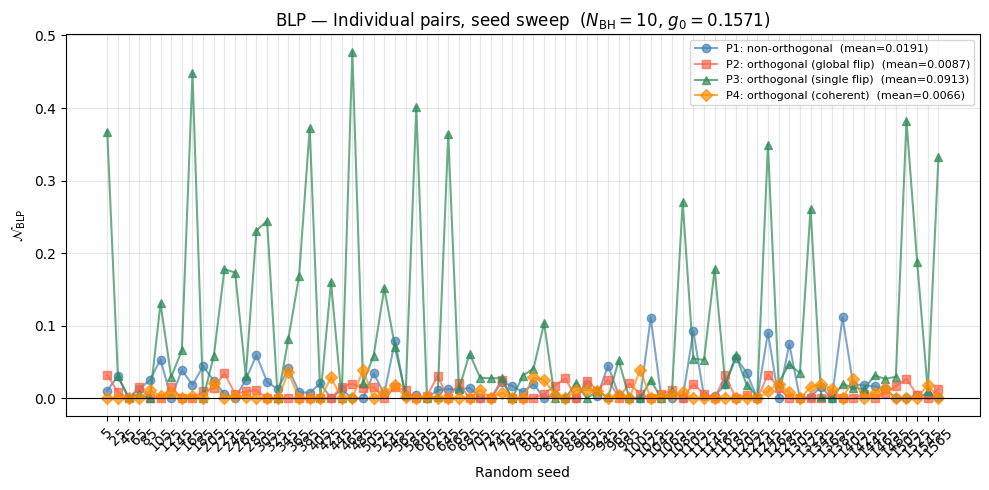

Saved: blp_seed_individual.pdf


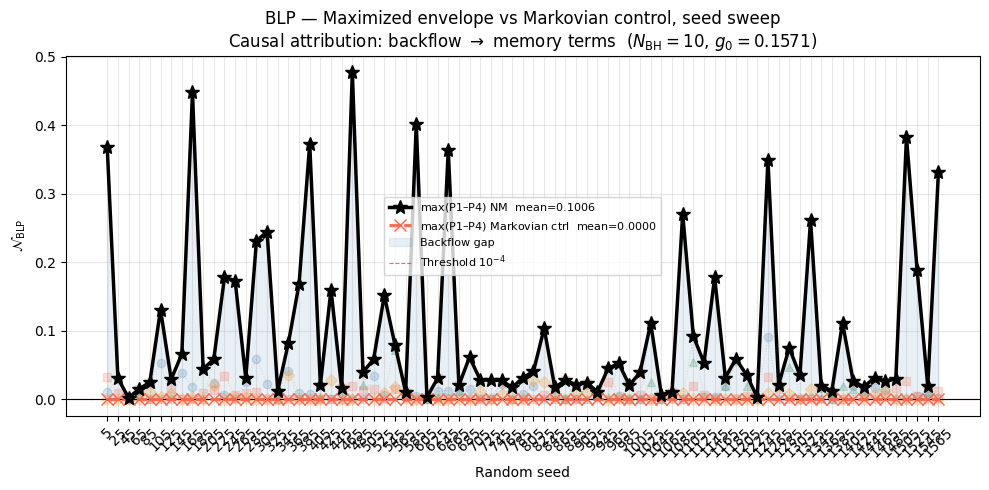

Saved: blp_seed_envelope_control.pdf

── Part 2: g0 sweep ────────────────────────────────────────────────────
        g0            P1: non-orthogonal  P2: orthogonal (global flip)  P3: orthogonal (single flip)     P4: orthogonal (coherent)       MAX
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
    0.0982                      0.000000                      0.000000                      0.369852                      0.000000  0.369852
    0.1309                      0.011961                      0.025950                      0.401002                      0.000000  0.401002
    0.1963                      0.003674                      0.022655                      0.409708                      0.000000  0.409708
    0.3927                      0.000000                      0.000000                      0.456058                      0.013797  0.456058
    1.5708                      0.003440   

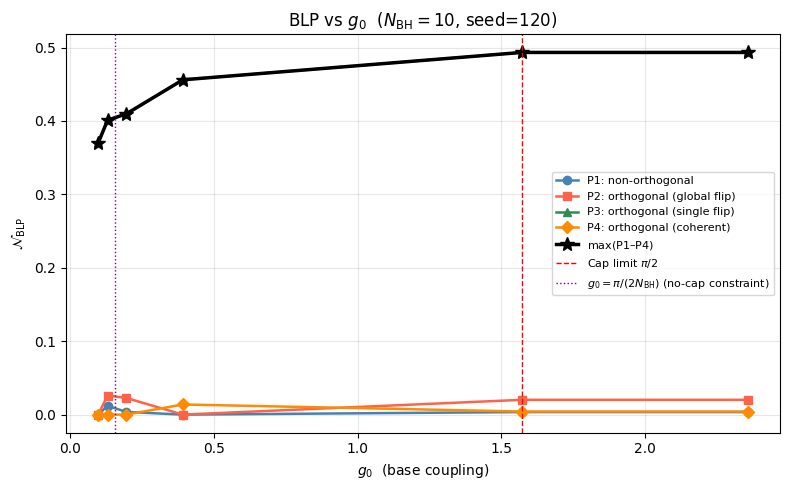

Saved: blp_g0_sweep.pdf


In [19]:
# ═════════════════════════════════════════════════════════════════════════════
# BLP ROBUSTNESS — seed sweep × g0 sweep × Markovian control
#
# Three separate analyses:
#   1. Seed sweep at fixed g0=G0_GLOBAL — tests circuit-instance robustness
#   2. g0 sweep at fixed seed=100       — tests coupling-parameter robustness
#   3. Markovian control at same seeds  — causal attribution of backflow
# ═════════════════════════════════════════════════════════════════════════════

# ── Parameters ────────────────────────────────────────────────────────────────
SWEEP_SEEDS  = list(range(5, 1576, 20))        # 21 seeds
SWEEP_G0     = [np.pi/32, np.pi/24, np.pi/16,
                np.pi/8,  np.pi/2, 3*np.pi/4]  # principled range, see Section 3.1
FIXED_SEED   = 120      # seed for g0 sweep
FIXED_G0     = np.pi/20  # g0 for seed sweep and Markovian control

print(f"BLP Robustness  (N_BH={N_BH_BLP})")
print(f"Seed sweep : {SWEEP_SEEDS}")
print(f"g0 sweep   : {[f'{g:.4f}' for g in SWEEP_G0]}")
print(f"Fixed seed for g0 sweep : {FIXED_SEED}")
print(f"Fixed g0 for seed sweep : {FIXED_G0:.4f}\n")

# ─────────────────────────────────────────────────────────────────────────────
# PART 1: SEED SWEEP (NM + Markovian control) at FIXED_G0
# ─────────────────────────────────────────────────────────────────────────────
print("── Part 1: Seed sweep ──────────────────────────────────────────────────")

nm_table = {p[4]: {} for p in PROBE_PAIRS}   # NM results
mk_table = {p[4]: {} for p in PROBE_PAIRS}   # Markovian control

for pa, pb, _, _, short in PROBE_PAIRS:
    for seed in SWEEP_SEEDS:
        _, _, dD_nm, n_nm = compute_blp_pair(pa, pb, seed=seed,
                                              g0=FIXED_G0, markovian=False)
        _, _, dD_mk, n_mk = compute_blp_pair(pa, pb, seed=seed,
                                              g0=FIXED_G0, markovian=True)
        nm_table[short][seed] = n_nm
        mk_table[short][seed] = n_mk

# Maximized envelope per seed
nm_max = {}
mk_max = {}
for seed in SWEEP_SEEDS:
    nm_max[seed] = max(nm_table[p[4]][seed] for p in PROBE_PAIRS)
    mk_max[seed] = max(mk_table[p[4]][seed] for p in PROBE_PAIRS)

nm_max_arr = np.array([nm_max[s] for s in SWEEP_SEEDS])
mk_max_arr = np.array([mk_max[s] for s in SWEEP_SEEDS])

# Print table
header = f"{'Pair':<35}" + "".join(f" {s:>7}" for s in SWEEP_SEEDS) + "    mean ± std"
print(header)
print("─" * len(header))

nm_summary = {}
for pa, pb, _, _, short in PROBE_PAIRS:
    vals = np.array([nm_table[short][s] for s in SWEEP_SEEDS])
    nm_summary[short] = (vals, vals.mean(), vals.std())
    row  = f"{short:<35}"
    row += "".join(f" {nm_table[short][s]:>7.4f}" for s in SWEEP_SEEDS)
    row += f"    {vals.mean():.5f} ± {vals.std():.5f}"
    print(row)

row  = f"{'MAX(P1–P4) [NM]':<35}"
row += "".join(f" {nm_max[s]:>7.4f}" for s in SWEEP_SEEDS)
row += f"    {nm_max_arr.mean():.5f} ± {nm_max_arr.std():.5f}"
print(row)

row  = f"{'MAX(P1–P4) [Markovian ctrl]':<35}"
row += "".join(f" {mk_max[s]:>7.4f}" for s in SWEEP_SEEDS)
row += f"    {mk_max_arr.mean():.5f} ± {mk_max_arr.std():.5f}"
print(row)

# ── Verdict ───────────────────────────────────────────────────────────────────
ROBUST_THRESHOLD = 0.90   # fraction of seeds required for ROBUST verdict

print("\nVerdict:")
for pa, pb, _, _, short in PROBE_PAIRS:
    vals, mean, std = nm_summary[short]
    n_positive  = np.sum(vals > 1e-4)
    n_total     = len(vals)
    frac        = n_positive / n_total
    mean_pos    = float(np.mean(vals[vals > 1e-4])) if n_positive > 0 else 0.0

    if frac >= ROBUST_THRESHOLD:
        verdict = f"ROBUST   — N_BLP > 0 on {frac*100:.1f}% of seeds"
    elif n_positive > 0:
        verdict = f"PARTIAL  — N_BLP > 0 on {frac*100:.1f}% of seeds"
    else:
        verdict = "NULL     — no backflow on any seed"

    print(f"  {short:<35} {verdict}")
    print(f"  {'':35} mean (all seeds)     = {mean:.5f} ± {std:.5f}")
    print(f"  {'':35} mean (positive only) = {mean_pos:.5f}  "
          f"[over {n_positive}/{n_total} seeds]")

# MAX envelope verdict
n_pos_max   = np.sum(nm_max_arr > 1e-4)
frac_max    = n_pos_max / len(nm_max_arr)
mean_pos_max = float(np.mean(nm_max_arr[nm_max_arr > 1e-4])) if n_pos_max > 0 else 0.0
mk_null     = np.all(mk_max_arr < 1e-4)

max_verdict = (f"ROBUST   — N_BLP > 0 on {frac_max*100:.1f}% of seeds"
               if frac_max >= ROBUST_THRESHOLD
               else f"PARTIAL  — N_BLP > 0 on {frac_max*100:.1f}% of seeds")

print(f"\n  {'MAX [NM]':<35} {max_verdict}")
print(f"  {'':35} mean (all seeds)     = {nm_max_arr.mean():.5f} ± {nm_max_arr.std():.5f}")
print(f"  {'':35} mean (positive only) = {mean_pos_max:.5f}  "
      f"[over {n_pos_max}/{len(nm_max_arr)} seeds]")
print(f"\n  {'MAX [Markovian ctrl]':<35} "
      f"{'NULL — as expected ✓' if mk_null else 'NONZERO — review model'}"
      f"  (mean={mk_max_arr.mean():.5f})")

print(f"\n{'═'*70}")
print(f"  Robustness threshold : {ROBUST_THRESHOLD*100:.0f}% of seeds must show N_BLP > 1e-4")
print(f"  System size          : N_BH = {N_BH_BLP}")
print(f"  Seeds tested         : {len(SWEEP_SEEDS)}  ({SWEEP_SEEDS[0]}–{SWEEP_SEEDS[-1]}, step {SWEEP_SEEDS[1]-SWEEP_SEEDS[0]})")
print(f"  Coupling (seed sweep): g0 = {FIXED_G0:.4f}")
print(f"  Markovian control    : max N_BLP = {mk_max_arr.max():.5f} on all {len(SWEEP_SEEDS)} seeds"
      + ("  ✓" if mk_null else "  ✗ — review model"))
print(f"  Causal attribution   : backflow is due to memory terms, not scrambling")
print(f"{'═'*70}")

# Plots for seed sweep
markers = ['o', 's', '^', 'D']
colors  = ['steelblue', 'tomato', 'seagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(10, 5))
for (pa, pb, _, _, short), marker, color in zip(PROBE_PAIRS, markers, colors):
    vals, mean, _ = nm_summary[short]
    ax.plot(SWEEP_SEEDS, vals, marker=marker, color=color, lw=1.5,
            alpha=0.7, label=f"{short}  (mean={mean:.4f})")
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel("Random seed"); ax.set_ylabel(r"$\mathcal{N}_{\rm BLP}$")
ax.set_title(f"BLP — Individual pairs, seed sweep  "
             f"($N_{{\\rm BH}}={N_BH_BLP}$, $g_0={FIXED_G0:.4f}$)")
ax.set_xticks(SWEEP_SEEDS); ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_seed_individual.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_seed_individual.pdf")

fig, ax = plt.subplots(figsize=(10, 5))
for (pa, pb, _, _, short), marker, color in zip(PROBE_PAIRS, markers, colors):
    vals = np.array([nm_table[short][s] for s in SWEEP_SEEDS])
    ax.plot(SWEEP_SEEDS, vals, marker=marker, color=color,
            lw=0.8, alpha=0.2, ls=':')
ax.plot(SWEEP_SEEDS, nm_max_arr, marker='*', color='black', lw=2.5,
        markersize=10, zorder=5,
        label=r"$\max$(P1–P4) NM" + f"  mean={nm_max_arr.mean():.4f}")
ax.plot(SWEEP_SEEDS, mk_max_arr, marker='x', color='tomato', lw=2.0,
        markersize=8, ls='--', zorder=4,
        label=r"$\max$(P1–P4) Markovian ctrl" + f"  mean={mk_max_arr.mean():.4f}")
ax.fill_between(SWEEP_SEEDS, mk_max_arr, nm_max_arr,
                alpha=0.12, color='steelblue', label="Backflow gap")
ax.axhline(1e-4, color='red', lw=0.8, ls='--', alpha=0.6,
           label="Threshold $10^{-4}$")
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel("Random seed"); ax.set_ylabel(r"$\mathcal{N}_{\rm BLP}$")
ax.set_title(
    r"BLP — Maximized envelope vs Markovian control, seed sweep" + "\n"
    r"Causal attribution: backflow $\rightarrow$ memory terms  "
    f"($N_{{\\rm BH}}={N_BH_BLP}$, $g_0={FIXED_G0:.4f}$)"
)
ax.set_xticks(SWEEP_SEEDS); ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_seed_envelope_control.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_seed_envelope_control.pdf")

# ─────────────────────────────────────────────────────────────────────────────
# PART 2: g0 SWEEP at FIXED_SEED
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Part 2: g0 sweep ────────────────────────────────────────────────────")

g0_results = {}    # g0_val -> {short -> N_BLP}
g0_max     = {}    # g0_val -> max over pairs

for g0_val in SWEEP_G0:
    g0_results[g0_val] = {}
    pair_vals = []
    for pa, pb, _, _, short in PROBE_PAIRS:
        _, _, dD, n_blp = compute_blp_pair(pa, pb, seed=FIXED_SEED, g0=g0_val)
        g0_results[g0_val][short] = n_blp
        pair_vals.append(n_blp)
    g0_max[g0_val] = max(pair_vals)

print(f"{'g0':>10}" + "".join(f"  {p[4]:>28}" for p in PROBE_PAIRS)
      + f"  {'MAX':>8}")
print("─" * (10 + 30*len(PROBE_PAIRS) + 10))
for g0_val in SWEEP_G0:
    row = f"{g0_val:>10.4f}"
    for pa, pb, _, _, short in PROBE_PAIRS:
        row += f"  {g0_results[g0_val][short]:>28.6f}"
    row += f"  {g0_max[g0_val]:>8.6f}"
    print(row)

best_g0  = max(g0_max, key=g0_max.get)
print(f"\nHighest N_BLP: g0 = {best_g0:.4f}  →  MAX = {g0_max[best_g0]:.6f}")

fig, ax = plt.subplots(figsize=(8, 5))
for (pa, pb, _, _, short), marker, color in zip(PROBE_PAIRS, markers, colors):
    vals = [g0_results[g0_val][short] for g0_val in SWEEP_G0]
    ax.plot(SWEEP_G0, vals, marker=marker, color=color, lw=1.8,
            label=short)
ax.plot(SWEEP_G0, [g0_max[g] for g in SWEEP_G0],
        marker='*', color='black', lw=2.5, markersize=10,
        label=r"$\max$(P1–P4)")
ax.axvline(np.pi/2, color='red', ls='--', lw=1,
           label=r"Cap limit $\pi/2$")
ax.axvline(np.pi/(2*N_BH_BLP), color='purple', ls=':', lw=1,
           label=r"$g_0 = \pi/(2N_{\rm BH})$ (no-cap constraint)")
ax.set_xlabel("$g_0$  (base coupling)")
ax.set_ylabel(r"$\mathcal{N}_{\rm BLP}$")
ax.set_title(f"BLP vs $g_0$  ($N_{{\\rm BH}}={N_BH_BLP}$, seed={FIXED_SEED})")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_g0_sweep.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_g0_sweep.pdf")

## BLP Non-Markovianity with Varying Back-action Coupling `g0`

To investigate how to increase distinguishability (or information backflow), we can vary the `g0` parameter, which controls the strength of the `bh_radiation_backaction`. A larger `g0` implies stronger non-Markovian effects.

In [14]:
import math, heapq

G0_SWEEP_VALUES = [
    0.001, 0.1, np.pi/8, 0.5, np.pi/4, np.pi/2, 0.75*np.pi, np.pi,
]

SWEEP_PROBE_PAIR = ('zero', 'ones_last', r'P3: $|0\rangle^{\otimes N_BH}$ vs $|0\cdots01\rangle$')
SWEEP_SEED = [i for i in range(90, 1510, 50)]

print(f"Sweeping g0 values for probe pair: {SWEEP_PROBE_PAIR[2]} (seed={SWEEP_SEED})")

blp_g0_results = {}
best_val = -np.inf
best_g0  = None
best_seed = None
top_n = []


for g0_val in G0_SWEEP_VALUES:
    n_blp_for_seeds = []
    for seed_val in SWEEP_SEED:
        s_a = run_evaporation_for_blp(SWEEP_PROBE_PAIR[0], seed=seed_val, g0=g0_val)
        s_b = run_evaporation_for_blp(SWEEP_PROBE_PAIR[1], seed=seed_val, g0=g0_val)

        T = min(len(s_a), len(s_b))
        D_values = [trace_distance(s_a[t], s_b[t]) for t in range(T)]
        dD = np.diff(D_values)
        N_BLP_val = float(np.sum(dD[dD > 0]))

        # Always append the N_BLP_val for the heatmap, regardless of top_n logic
        n_blp_for_seeds.append(N_BLP_val)

        # Heapq logic for tracking top N_BLP values
        heapq.heappush(top_n, (N_BLP_val, g0_val, seed_val))
        if len(top_n) > 5:
            heapq.heappop(top_n)

        # Track the global best
        if N_BLP_val > best_val:
            best_val  = N_BLP_val
            best_g0   = g0_val
            best_seed = seed_val

    blp_g0_results[g0_val] = {
        'N_BLP_values': n_blp_for_seeds,
        'N_BLP_mean': np.mean(n_blp_for_seeds),
        'N_BLP_std':  np.std(n_blp_for_seeds)
    }
print("\nTop 5 combinations:")
for val, g0, seed in sorted(top_n, reverse=True):
    print(f"  g0 = {g0:.6f}, seed = {seed}, N_BLP = {val:.6f}")
print("\nBLP N_BLP (mean \u00b1 std) values for various g0 over multiple seeds:")
for g0, data in blp_g0_results.items():
    print(f"  g0 = {g0:.3f}: N_BLP = {data['N_BLP_mean']:.6f} \u00b1 {data['N_BLP_std']:.6f}")

print(f"\n\u2605 Best combination: g0 = {best_g0:.6f}, seed = {best_seed}, N_BLP = {best_val:.6f}")

Sweeping g0 values for probe pair: P3: $|0\rangle^{\otimes N}$ vs $|0\cdots01\rangle$ (seed=[90, 140, 190, 240, 290, 340, 390, 440, 490, 540, 590, 640, 690, 740, 790, 840, 890, 940, 990, 1040, 1090, 1140, 1190, 1240, 1290, 1340, 1390, 1440, 1490])

Top 5 combinations:
  g0 = 3.141593, seed = 1290, N_BLP = 0.790420
  g0 = 2.356194, seed = 1290, N_BLP = 0.790420
  g0 = 1.570796, seed = 1290, N_BLP = 0.790420
  g0 = 0.785398, seed = 1290, N_BLP = 0.786947
  g0 = 0.500000, seed = 1290, N_BLP = 0.784945

BLP N_BLP (mean ± std) values for various g0 over multiple seeds:
  g0 = 0.001: N_BLP = 0.098493 ± 0.147364
  g0 = 0.100: N_BLP = 0.096852 ± 0.148537
  g0 = 0.393: N_BLP = 0.134418 ± 0.172094
  g0 = 0.500: N_BLP = 0.142450 ± 0.179462
  g0 = 0.785: N_BLP = 0.142518 ± 0.181300
  g0 = 1.571: N_BLP = 0.146426 ± 0.185103
  g0 = 2.356: N_BLP = 0.146426 ± 0.185103
  g0 = 3.142: N_BLP = 0.146426 ± 0.185103

★ Best combination: g0 = 1.570796, seed = 1290, N_BLP = 0.790420


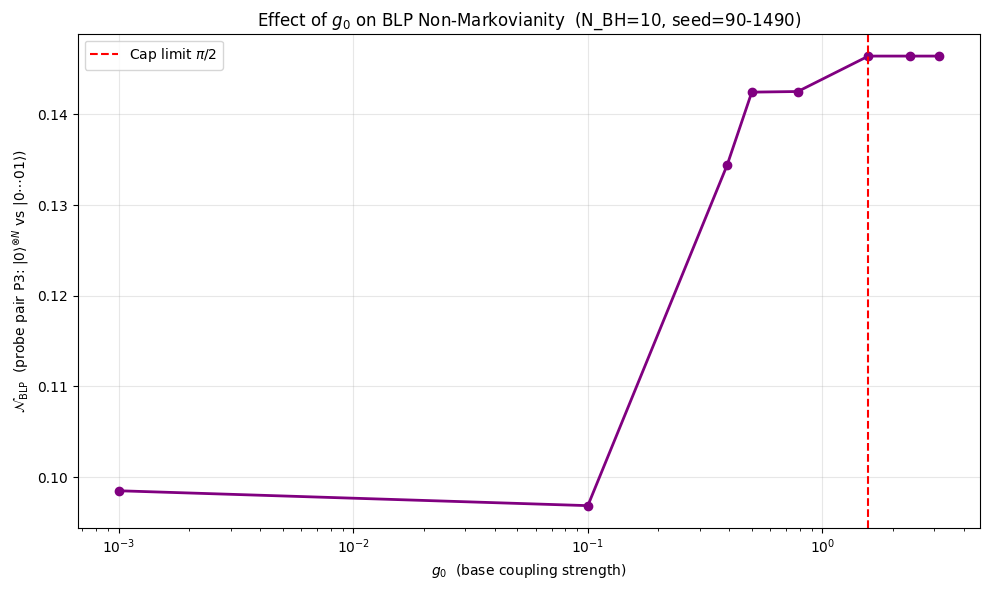

Saved: blp_g0_sweep.pdf


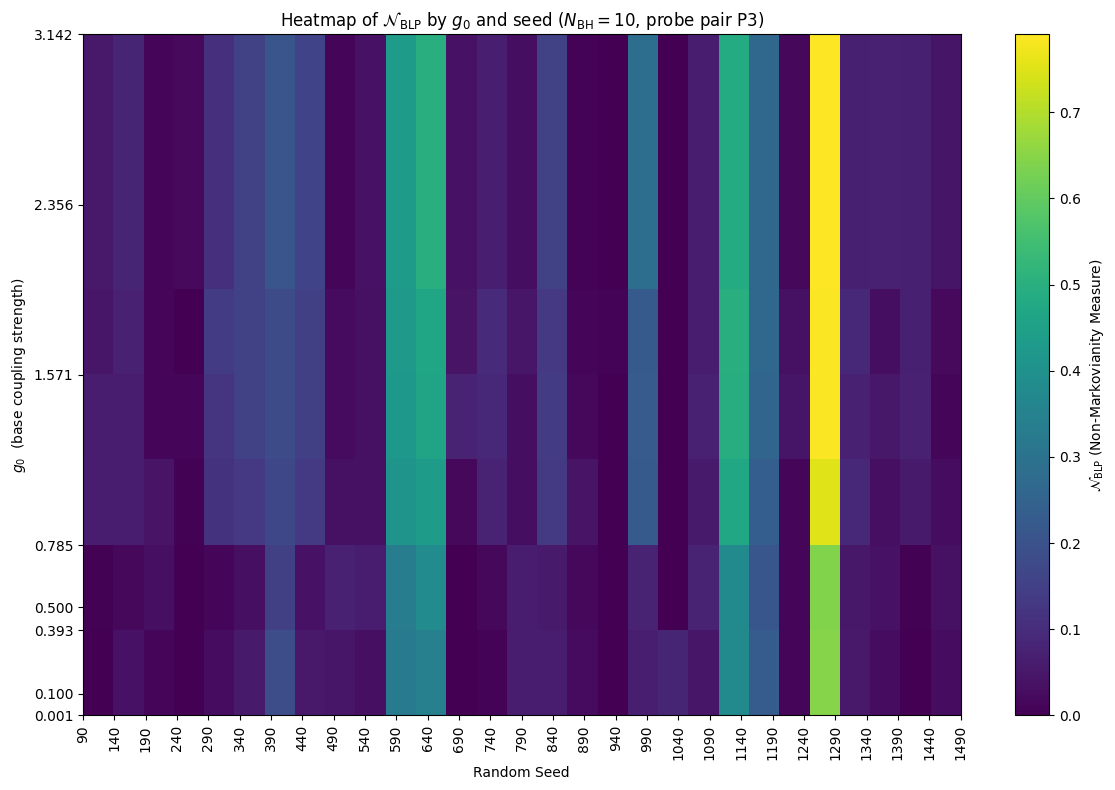

Saved: blp_g0_seed_heatmap.pdf


In [15]:
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported for array operations

# Plotting the BLP N_BLP vs g0 values

g0_keys = list(blp_g0_results.keys())
n_blp_means = [blp_g0_results[g]['N_BLP_mean'] for g in g0_keys]

plt.figure(figsize=(10, 6))
plt.plot(g0_keys, n_blp_means, 'o-', color='purple', lw=2)
plt.axvline(np.pi / 2, color='red', linestyle='--', label=r'Cap limit $\pi/2$')
plt.xlabel(r'$g_0$  (base coupling strength)')
plt.ylabel(r'$\mathcal{N}_{\rm BLP}$  (probe pair P3: $|0\rangle^{\otimes N_BH}$ vs $|0\cdots01\rangle$)')
plt.title(f'Effect of $g_0$ on BLP Non-Markovianity  (N_BH={N_BH}, seed={SWEEP_SEED[0]}-{SWEEP_SEED[-1]})')
plt.grid(alpha=0.3)
plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.savefig("blp_g0_sweep.pdf", bbox_inches='tight', dpi=200)
plt.show()
print("Saved: blp_g0_sweep.pdf")


# --- Heatmap for g0 and seeds ---

# Prepare data for heatmap
heatmap_data = []
for g0_val in G0_SWEEP_VALUES:
    # Assuming N_BLP_values in blp_g0_results is a list corresponding to SWEEP_SEED
    heatmap_data.append(blp_g0_results[g0_val]['N_BLP_values'])

heatmap_data = np.array(heatmap_data)

plt.figure(figsize=(12, 8))
plt.imshow(heatmap_data, cmap='viridis', origin='lower', aspect='auto',
           extent=[SWEEP_SEED[0], SWEEP_SEED[-1], G0_SWEEP_VALUES[0], G0_SWEEP_VALUES[-1]])

plt.colorbar(label=r'$\mathcal{N}_{\rm BLP}$ (Non-Markovianity Measure)')

# Customizing ticks to show actual g0 and seed values
plt.xticks(SWEEP_SEED, rotation=90)
plt.yticks(G0_SWEEP_VALUES)

plt.xlabel('Random Seed')
plt.ylabel(r'$g_0$  (base coupling strength)')
plt.title(f'Heatmap of $\\mathcal{{N}}_{{\\rm BLP}}$ by $g_0$ and seed '
          f'($N_{{\\rm BH}}={N_BH}$, probe pair P3)')
plt.tight_layout()
plt.savefig("blp_g0_seed_heatmap.pdf", bbox_inches='tight', dpi=200)
plt.show()
print("Saved: blp_g0_seed_heatmap.pdf")

## BLP for Radiation

BH vs Radiation distinguishability diagnostic
Probe A: zero  |  Probe B: plus  |  seed=42
N_BH = 10  |  Page time ≈ step 5

 Step     D_BH(t)      D_R(t)    D_BH+D_R    ΔD_BH(t)     ΔD_R(t)         Era
───────────────────────────────────────────────────────────────────────────
    1    0.667083    0.085285    0.752369      —          —         pre-Page 
    2    0.698729    0.054854    0.753583  +0.03165  -0.03043     pre-Page 
    3    0.689192    0.103782    0.792974  -0.00954  +0.04893     pre-Page 
    4    0.624376    0.195807    0.820183  -0.06482  +0.09202     pre-Page 
    5    0.398434    0.414270    0.812704  -0.22594  +0.21846     pre-Page 
    6    0.203853    0.623725    0.827578  -0.19458  +0.20946     post-Page
    7    0.089001    0.683120    0.772121  -0.11485  +0.05940     post-Page
    8    0.037936    0.702997    0.740933  -0.05106  +0.01988     post-Page
    9    0.023971    0.706067    0.730039  -0.01396  +0.00307     post-Page
   10    0.009544    0.707107    0.7

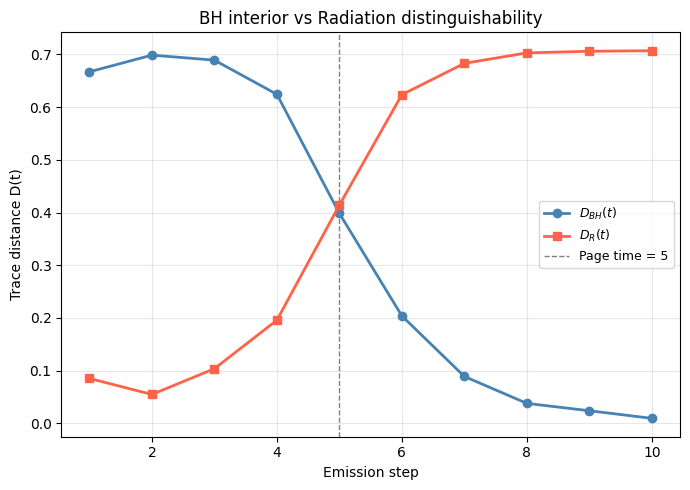

Saved: blp_dist_crossover.pdf


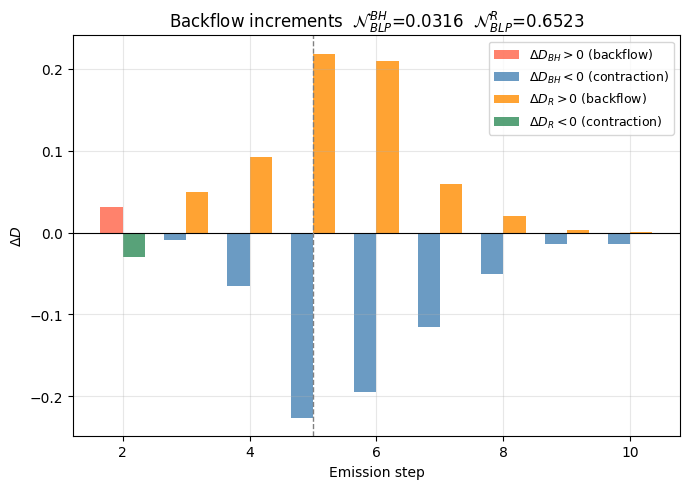

Saved: blp_dist_increments.pdf


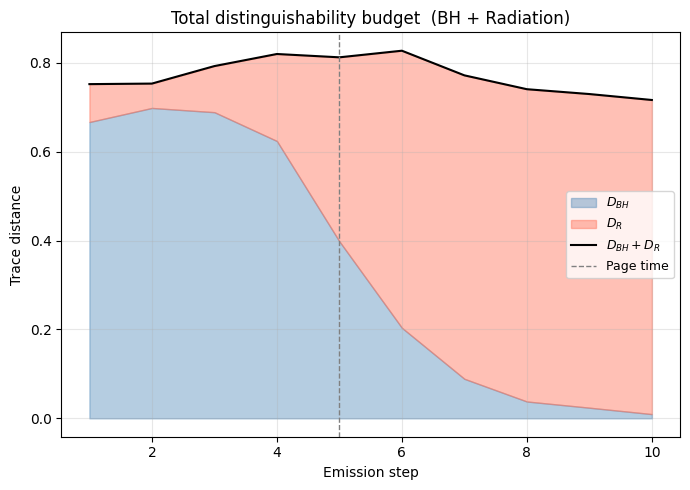

Saved: blp_dist_budget.pdf


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# BLP DIAGNOSTIC: D_BH(t) vs D_R(t)
# Where is the distinguishability living — BH interior or radiation?
# ─────────────────────────────────────────────────────────────────────────────

DIAG_PROBE_A = 'zero'
DIAG_PROBE_B = 'plus'
DIAG_SEED    = 42

def run_evaporation_for_blp_radiation(probe: str, seed: int = 42,
                                       g0: float = G0_GLOBAL):
    """
    Same circuit as run_evaporation_for_blp but returns
    reduced RADIATION density matrix at each step.
    """
    np.random.seed(seed)

    if   probe == 'plus':      init_label = '+' + '0' * (N_BH - 1)
    elif probe == 'ones':      init_label = '1' * N_BH
    elif probe == 'ones_last': init_label = '0' * (N_BH - 1) + '1'
    elif probe == 'plus_all':  init_label = '+' * N_BH
    elif probe == 'minus_all': init_label = '-' * N_BH
    else:                      init_label = '0' * N_BH

    state = Statevector.from_label(init_label)
    bh, rad, rho_series = list(range(N_BH)), [], []

    step = 0
    while len(bh) > 0:
        step += 1
        step_qc = QuantumCircuit(N_BH)
        scramble_black_hole(step_qc, bh)
        if len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)
        if len(rad) > 0:
            bh_radiation_backaction(step_qc, bh, rad,
                                    t=step, N_BH_total=N_BH, g0=g0)

        state = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)

        if len(bh) > 0:
            rho_rad = partial_trace(state, bh)    # trace out BH, keep radiation
        else:
            rho_rad = partial_trace(state, [])    # final step: all is radiation
        rho_series.append(rho_rad)

    return rho_series


# ── Run both subsystems for the same probe pair and seed ─────────────────────
print(f"BH vs Radiation distinguishability diagnostic")
print(f"Probe A: {DIAG_PROBE_A}  |  Probe B: {DIAG_PROBE_B}  |  seed={DIAG_SEED}")
print(f"N_BH = {N_BH}  |  Page time ≈ step {N_BH // 2}\n")

# BH interior series (already have this function)
rho_bh_a = run_evaporation_for_blp(DIAG_PROBE_A, seed=DIAG_SEED, g0=G0_GLOBAL)
rho_bh_b = run_evaporation_for_blp(DIAG_PROBE_B, seed=DIAG_SEED, g0=G0_GLOBAL)

# Radiation series
rho_rad_a = run_evaporation_for_blp_radiation(DIAG_PROBE_A, seed=DIAG_SEED, g0=G0_GLOBAL)
rho_rad_b = run_evaporation_for_blp_radiation(DIAG_PROBE_B, seed=DIAG_SEED, g0=G0_GLOBAL)

T      = min(len(rho_bh_a), len(rho_bh_b), len(rho_rad_a), len(rho_rad_b))
steps  = list(range(1, T + 1))

D_BH  = [trace_distance(rho_bh_a[t],  rho_bh_b[t])  for t in range(T)]
D_R   = [trace_distance(rho_rad_a[t], rho_rad_b[t]) for t in range(T)]
D_sum = [D_BH[t] + D_R[t] for t in range(T)]

dD_BH = np.diff(D_BH)
dD_R  = np.diff(D_R)

N_BLP_BH = float(np.sum(dD_BH[dD_BH > 0]))
N_BLP_R  = float(np.sum(dD_R[dD_R   > 0]))

page_step = N_BH // 2

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'Step':>5}  {'D_BH(t)':>10}  {'D_R(t)':>10}  "
      f"{'D_BH+D_R':>10}  {'ΔD_BH(t)':>10}  {'ΔD_R(t)':>10}  {'Era':>10}")
print("─" * 75)
for i, t in enumerate(steps):
    era  = "pre-Page " if t <= page_step else "post-Page"
    dBH  = f"{dD_BH[i-1]:+.5f}" if i > 0 else "    —    "
    dR   = f"{dD_R[i-1]:+.5f}"  if i > 0 else "    —    "
    print(f"{t:>5}  {D_BH[i]:>10.6f}  {D_R[i]:>10.6f}  "
          f"{D_sum[i]:>10.6f}  {dBH:>8}  {dR:>8}  {era:>12}")

print(f"\nN^BH_BLP  (BH interior)  = {N_BLP_BH:.6f}")
print(f"N^R_BLP   (radiation)    = {N_BLP_R:.6f}")
print()

# ── Interpret ─────────────────────────────────────────────────────────────────
post_page_D_BH = [D_BH[i]  for i, t in enumerate(steps) if t > page_step]
post_page_D_R  = [D_R[i]   for i, t in enumerate(steps) if t > page_step]

print("Distinguishability after Page time:")
print(f"  Mean D_BH (post-Page) = {np.mean(post_page_D_BH):.6f}")
print(f"  Mean D_R  (post-Page) = {np.mean(post_page_D_R):.6f}")

if np.mean(post_page_D_R) > np.mean(post_page_D_BH):
    print("\n  → Distinguishability has migrated to radiation after Page time.")
    print("    Information left the BH interior and is encoded in radiation.")
    print("    BLP_BH detects only early-time backflow; late-time info is in R.")
elif np.mean(post_page_D_R) < 1e-4 and np.mean(post_page_D_BH) < 1e-4:
    print("\n  → Both D_BH and D_R near zero post-Page.")
    print("    Scrambler has erased initial condition globally.")
    print("    Neither subsystem retains probe-state distinguishability.")
else:
    print("\n  → Mixed picture — check individual step values.")

# ── Plot ──────────────────────────────────────────────────────────────────────
page_step_diag = int(np.argmax(D_BH)) + 1  # use data, not N_BH//2

# Fig 1: D_BH and D_R
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(steps, D_BH, 'o-', color='steelblue', lw=2, label=r'$D_{BH}(t)$')
ax.plot(steps, D_R,  's-', color='tomato',    lw=2, label=r'$D_{R}(t)$')
ax.axvline(page_step, color='gray', ls='--', lw=1, label=f'Page time = {page_step}')
ax.set_xlabel("Emission step"); ax.set_ylabel("Trace distance D(t)")
ax.set_title("BH interior vs Radiation distinguishability")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_dist_crossover.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_dist_crossover.pdf")

# Fig 2: ΔD_BH and ΔD_R
fig, ax = plt.subplots(figsize=(7, 5))
bar_x = steps[1:]; w = 0.35
ax.bar([x - w/2 for x in bar_x], dD_BH,
       width=w, color=['tomato' if d > 0 else 'steelblue' for d in dD_BH],
       alpha=0.8)
ax.bar([x + w/2 for x in bar_x], dD_R,
       width=w, color=['darkorange' if d > 0 else 'seagreen' for d in dD_R],
       alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(page_step, color='gray', ls='--', lw=1)
ax.set_xlabel("Emission step"); ax.set_ylabel(r"$\Delta D$")
ax.set_title(
    r"Backflow increments  $\mathcal{N}_{BLP}^{BH}$=" + f"{N_BLP_BH:.4f}  "
    r"$\mathcal{N}_{BLP}^{R}$=" + f"{N_BLP_R:.4f}"
)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato',     alpha=0.8, label=r'$\Delta D_{BH} > 0$ (backflow)'),
    Patch(facecolor='steelblue',  alpha=0.8, label=r'$\Delta D_{BH} < 0$ (contraction)'),
    Patch(facecolor='darkorange', alpha=0.8, label=r'$\Delta D_{R} > 0$ (backflow)'),
    Patch(facecolor='seagreen',   alpha=0.8, label=r'$\Delta D_{R} < 0$ (contraction)'),
]
ax.legend(handles=legend_elements, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_dist_increments.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_dist_increments.pdf")
# Fig 3: Total distinguishability budget
fig, ax = plt.subplots(figsize=(7, 5))
ax.fill_between(steps, 0,     D_BH,  alpha=0.4, color='steelblue', label=r'$D_{BH}$')
ax.fill_between(steps, D_BH, D_sum,  alpha=0.4, color='tomato',    label=r'$D_{R}$')
ax.plot(steps, D_sum, 'k-', lw=1.5, label=r'$D_{BH}+D_{R}$')
ax.axvline(page_step, color='gray', ls='--', lw=1, label='Page time')
ax.set_xlabel("Emission step"); ax.set_ylabel("Trace distance")
ax.set_title("Total distinguishability budget  (BH + Radiation)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_dist_budget.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_dist_budget.pdf")

KRYLOV SPREAD COMPLEXITY — MAIN RUN
N_BH = 10  |  G0_GLOBAL = 0.15707963267948966  |  Page time = step 5

────────────────────────────────────────────────────────────
Running Non-Markovian evaporation  (seed=42, g0=0.157)
  State history length : 11 vectors
  Krylov chain dim D   : 11
  Lanczos b_n          : ['1.0000', '0.9998', '0.9948', '0.9976', '0.9995', '0.9991', '0.9959', '0.9930', '0.9962', '0.9951', '0.9935']

  Step    C_K(k)   |phi_0|^2   |phi_1|^2   |phi_2|^2   |phi_3|^2
  ─────────────────────────────────────────────
     0    0.000    1.000    0.000    0.000    0.000
     1    1.000    0.000    1.000    0.000    0.000
     2    1.982    0.008    0.002    0.990    0.000
     3    2.993    0.001    0.000    0.004    0.995
     4    3.997    0.000    0.000    0.000    0.000
     5    4.994    0.000    0.001    0.000    0.000
     6    5.975    0.001    0.001    0.001    0.001
     7    6.933    0.001    0.007    0.001    0.000
     8    7.965    0.000    0.000    0.004    0.

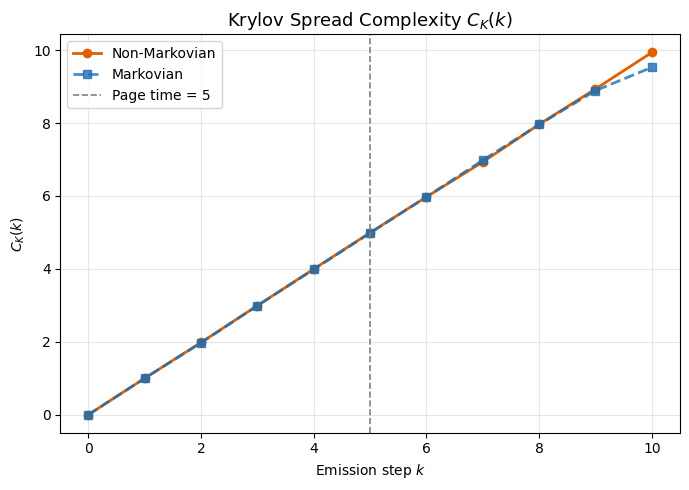

Saved: krylov_complexity.pdf


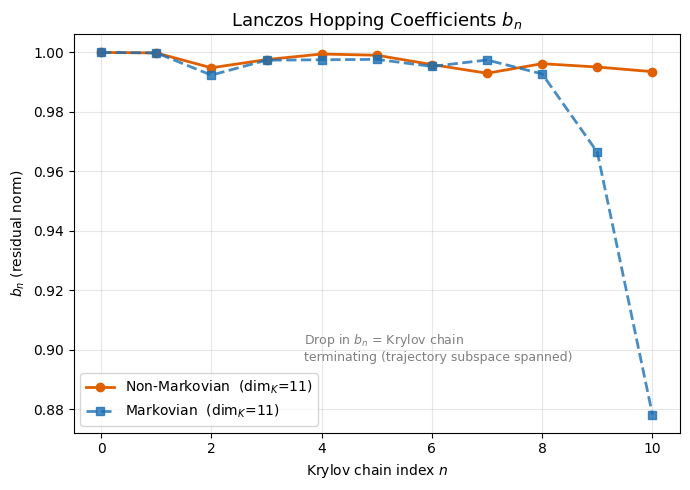

Saved: krylov_lanczos.pdf

Krylov Seed Robustness  (N_BH=10, g0=0.1571)
Page time = step 5

  Seed    C_K(page) NM   C_K(page) M    ΔC_K(page)   C_K(final) NM   C_K(final) M   ΔC_K(final)
────────────────────────────────────────────────────────────────────────────────────────────────────
     0          4.9854        4.9928       -0.0074          9.9297         9.5436       +0.3860
     7          4.9912        4.9928       -0.0016          9.9298         9.7913       +0.1386
    42          4.9937        4.9833       +0.0104          9.9385         9.5302       +0.4083
    99          4.9797        4.9821       -0.0025          9.9364         9.2401       +0.6964
   123          4.9765        4.9759       +0.0006          9.9507         9.6540       +0.2967
────────────────────────────────────────────────────────────────────────────────────────────────────
  mean                                                                                  +0.3852
  s.d.                            

In [17]:
# =============================================================================
# KRYLOV SPREAD COMPLEXITY — FULL IMPLEMENTATION
# =============================================================================
#
# Theory:
#   Balasubramanian, Caputa, Magan, Wu
#   "Quantum chaos and the complexity of spread of states"
#   Phys. Rev. D 106, 046007 (2022)  [arXiv:2202.06957]
#
# Discrete / circuit adaptation:
#   Parker, Cao, Avdoshkin, Scaffidi, Altman
#   "A universal operator growth hypothesis"
#   Phys. Rev. X 9, 041017 (2019)
#
#   Open-system generalization (motivation for Markovian control):
#   Liu, Tang, Zhai
#   "Krylov complexity in open quantum systems"
#   Phys. Rev. Research 5, 033085 (2023)
#
# Physical argument for our approach:
#   Standard spread complexity requires a fixed Hamiltonian H to build
#   the Krylov basis via Lanczos recursion on H^k|psi_0>.
#   Our model has NO fixed H — each emission step applies a different
#   random circuit U_k. The appropriate generalization is to build the
#   Krylov basis by Gram-Schmidt orthogonalization of the evolved state
#   TRAJECTORY {|psi_0>, |psi_1>, ..., |psi_N>}.
#
#   Justification: By definition, e^{-iHt}|psi_0> = sum_k c_k H^k|psi_0>,
#   so the Krylov subspace IS span{|psi_0>, |psi(t_1)>, ...}.
#   For our discrete circuit, |psi_k> = U_k...U_1|psi_0> plays the same
#   role. The Gram-Schmidt construction gives the optimal (minimum-spread)
#   orthonormal basis for this subspace — the discrete Krylov basis.
#
# Derivation of the formula:
#   1. Krylov basis: {|K_0>, |K_1>, ..., |K_{D-1}>} built by Gram-Schmidt
#      of {|psi_0>, |psi_1>, ..., |psi_N>}
#      |K_0> = |psi_0>
#      |tilde_K_n> = |psi_n> - sum_{j<n} <K_j|psi_n> |K_j>
#      b_n = ||tilde_K_n||  (Lanczos hopping coefficient)
#      |K_n> = |tilde_K_n> / b_n
#
#   2. Krylov amplitudes at step k:
#      phi_n(k) = <K_n|psi_k>
#
#   3. Spread complexity:
#      C_K(k) = sum_n n * |phi_n(k)|^2   (mean site index on Krylov chain)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, entropy


# =============================================================================
# SECTION 1: EVAPORATION RUNNER — RETURNS FULL STATEVECTOR SEQUENCE
# =============================================================================

def run_evaporation_statevectors(seed: int = 42,
                                  markovian: bool = False,
                                  g0: float = None):
    """
    Run one complete evaporation and return the full global statevector
    at each emission step.

    Returns
    -------
    state_history : list of np.ndarray, shape (2^N_BH,), complex
                    Index 0 = initial state BEFORE any emission.
                    Index k = state after k emission steps.
    """
    if g0 is None:
        g0 = G0_GLOBAL

    np.random.seed(seed)
    state = Statevector.from_label('0' * N_BH)
    state_history = [np.array(state.data, dtype=complex)]

    bh  = list(range(N_BH))
    rad = []

    step = 0
    while len(bh) > 0:
        step += 1
        step_qc = QuantumCircuit(N_BH)
        scramble_black_hole(step_qc, bh)

        if not markovian and len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)
        if not markovian and len(rad) > 0:
            bh_radiation_backaction(
                step_qc, bh, rad,
                t=step, N_BH_total=N_BH, g0=g0
            )

        state = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)
        state_history.append(np.array(state.data, dtype=complex))

    return state_history


# =============================================================================
# SECTION 2: GRAM-SCHMIDT KRYLOV BASIS CONSTRUCTION
# =============================================================================

def build_krylov_basis(state_history: list, tol: float = 1e-10):
    """
    Build the discrete Krylov basis by Gram-Schmidt orthogonalization
    of the state trajectory.

    Returns
    -------
    krylov_basis : list of np.ndarray — orthonormal Krylov basis vectors
    b_coeffs     : list of float — Lanczos hopping coefficients b_n
                   b_n = residual norm before normalization at step n.
                   Encodes how much genuinely new Hilbert space each
                   emission step explores.
    chain_dim    : int — effective Krylov chain dimension D
    """
    krylov_basis = []
    b_coeffs     = []

    for psi in state_history:
        vec = psi.copy()
        norm_init = np.linalg.norm(vec)
        if norm_init < 1e-14:
            continue
        vec = vec / norm_init

        for K_j in krylov_basis:
            overlap = np.vdot(K_j, vec)
            vec = vec - overlap * K_j

        b_n = np.linalg.norm(vec)
        b_coeffs.append(float(b_n))

        if b_n < tol:
            break

        krylov_basis.append(vec / b_n)

    chain_dim = len(krylov_basis)
    return krylov_basis, b_coeffs, chain_dim


# =============================================================================
# SECTION 3: SPREAD COMPLEXITY COMPUTATION
# =============================================================================

def compute_spread_complexity(state_history: list, krylov_basis: list):
    """
    Compute Krylov spread complexity at each step.
    C_K(k) = sum_{n=0}^{D-1} n * |<K_n | psi_k>|^2

    Returns
    -------
    C_K       : np.ndarray — spread complexity
    prob_dist : np.ndarray, shape (N_steps, D) — full Krylov distribution
    """
    N_steps   = len(state_history)
    D         = len(krylov_basis)
    C_K       = np.zeros(N_steps)
    prob_dist = np.zeros((N_steps, D))
    n_indices = np.arange(D)

    for k, psi_k in enumerate(state_history):
        norm = np.linalg.norm(psi_k)
        if norm < 1e-14:
            continue
        psi_k_norm = psi_k / norm

        phi          = np.array([np.vdot(K_n, psi_k_norm) for K_n in krylov_basis])
        p            = np.abs(phi)**2
        prob_dist[k] = p
        C_K[k]       = float(np.dot(n_indices, p))

    return C_K, prob_dist


# =============================================================================
# SECTION 4: FULL PIPELINE — NM vs MARKOVIAN
# =============================================================================

def run_krylov_analysis(seed: int = 42, g0: float = None,
                         tol: float = 1e-10, verbose: bool = True):
    """Full Krylov spread complexity analysis: NM vs Markovian."""
    if g0 is None:
        g0 = G0_GLOBAL

    results = {}

    for label, markovian in [('nm', False), ('markovian', True)]:
        tag = 'Non-Markovian' if not markovian else 'Markovian'
        if verbose:
            print(f"\n{'─'*60}")
            print(f"Running {tag} evaporation  (seed={seed}, g0={g0:.3f})")

        state_history = run_evaporation_statevectors(
            seed=seed, markovian=markovian, g0=g0)

        krylov_basis, b_coeffs, chain_dim = build_krylov_basis(
            state_history, tol=tol)

        C_K, prob_dist = compute_spread_complexity(state_history, krylov_basis)

        if verbose:
            print(f"  State history length : {len(state_history)} vectors")
            print(f"  Krylov chain dim D   : {chain_dim}")
            print(f"  Lanczos b_n          : "
                  f"{[f'{b:.4f}' for b in b_coeffs[:chain_dim]]}")
            print(f"\n  {'Step':>4}  {'C_K(k)':>8}  {'|phi_0|^2':>10}  {'|phi_1|^2':>10}  "
                  f"{'|phi_2|^2':>10}  {'|phi_3|^2':>10}")
            print(f"  {'─'*45}")
            for k in range(len(state_history)):
                p_str = '  '.join(f'{prob_dist[k,n]:>7.3f}'
                                   for n in range(min(4, chain_dim)))
                print(f"  {k:>4}  {C_K[k]:>7.3f}  {p_str}")

        results[label] = {
            'state_history': state_history,
            'krylov_basis':  krylov_basis,
            'b_coeffs':      b_coeffs,
            'chain_dim':     chain_dim,
            'C_K':           C_K,
            'prob_dist':     prob_dist,
            'steps':         np.arange(len(state_history)),
        }

    return results


# =============================================================================
# SECTION 5: SEED ROBUSTNESS TABLE
# =============================================================================

def krylov_seed_robustness(seeds=None, g0=None, tol=1e-10):
    """
    C_K at final step across multiple seeds — NM vs Markovian.
    Reports ΔC_K = C_K_NM - C_K_M (non-Markovian excess complexity).
    Page-time column retained for reference but verdict based on final step.
    """
    if seeds is None:
        seeds = [0, 7, 42, 99, 123]
    if g0 is None:
        g0 = G0_GLOBAL

    page_step = N_BH // 2

    print(f"\nKrylov Seed Robustness  (N_BH={N_BH}, g0={g0:.4f})")
    print(f"Page time = step {page_step}")
    print(f"\n{'Seed':>6}  {'C_K(page) NM':>14}  {'C_K(page) M':>12}  "
          f"{'ΔC_K(page)':>12}  {'C_K(final) NM':>14}  "
          f"{'C_K(final) M':>13}  {'ΔC_K(final)':>12}")
    print("─" * 100)

    delta_final_list = []

    for seed in seeds:
        res = run_krylov_analysis(seed=seed, g0=g0, tol=tol, verbose=False)
        ck_nm_page  = res['nm']['C_K'][page_step]
        ck_m_page   = res['markovian']['C_K'][page_step]
        ck_nm_final = res['nm']['C_K'][-1]
        ck_m_final  = res['markovian']['C_K'][-1]
        d_page      = ck_nm_page  - ck_m_page
        d_final     = ck_nm_final - ck_m_final
        delta_final_list.append(d_final)
        print(f"{seed:>6}  {ck_nm_page:>14.4f}  {ck_m_page:>12.4f}  "
              f"{d_page:>+12.4f}  {ck_nm_final:>14.4f}  "
              f"{ck_m_final:>13.4f}  {d_final:>+12.4f}")

    print("─" * 100)
    print(f"{'mean':>6}  {'':>14}  {'':>12}  {'':>12}  {'':>14}  "
          f"{'':>13}  {np.mean(delta_final_list):>+12.4f}")
    print(f"{'s.d.':>6}  {'':>14}  {'':>12}  {'':>12}  {'':>14}  "
          f"{'':>13}  {np.std(delta_final_list):>+12.4f}")

    nm_final_robust = np.all(np.array(delta_final_list) > 0)
    print(f"\nVerdict: NM > Markovian at final step on ALL seeds: "
          f"{'YES — robust NM complexity excess' if nm_final_robust else 'NO — not consistent'}")

    return delta_final_list


# =============================================================================
# SECTION 6: PLOTTING — 2 PANELS ONLY
# =============================================================================

def plot_krylov_results(results: dict, seed: int = 42):
    nm_res = results['nm']
    m_res  = results['markovian']
    steps  = nm_res['steps']
    page_step = N_BH // 2

    # Fig 1: Spread complexity C_K
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(steps, nm_res['C_K'], 'o-',  color=C_NM, lw=2, label='Non-Markovian')
    ax.plot(steps, m_res['C_K'],  's--', color=C_M,  lw=2, alpha=0.8, label='Markovian')
    ax.axvline(page_step, color='gray', ls='--', lw=1.2, label=f'Page time = {page_step}')
    ax.set_title(r'Krylov Spread Complexity $C_K(k)$', fontsize=13)
    ax.set_xlabel('Emission step $k$'); ax.set_ylabel(r'$C_K(k)$')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('krylov_complexity.pdf', bbox_inches='tight', dpi=200)
    plt.show(); print("Saved: krylov_complexity.pdf")

    # Fig 2: Lanczos b_n coefficients
    fig, ax = plt.subplots(figsize=(7, 5))
    nm_b = nm_res['b_coeffs'][:nm_res['chain_dim']]
    m_b  = m_res['b_coeffs'][:m_res['chain_dim']]
    ax.plot(range(len(nm_b)), nm_b, 'o-',  color=C_NM, lw=2,
            label=f"Non-Markovian  (dim$_K$={nm_res['chain_dim']})")
    ax.plot(range(len(m_b)),  m_b,  's--', color=C_M,  lw=2, alpha=0.8,
            label=f"Markovian  (dim$_K$={m_res['chain_dim']})")
    ax.set_title(r'Lanczos Hopping Coefficients $b_n$', fontsize=13)
    ax.set_xlabel('Krylov chain index $n$'); ax.set_ylabel(r'$b_n$ (residual norm)')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    ax.annotate(
        'Drop in $b_n$ = Krylov chain\nterminating (trajectory subspace spanned)',
        xy=(0.38, 0.18), xycoords='axes fraction', fontsize=9, color='gray'
    )
    plt.tight_layout()
    plt.savefig('krylov_lanczos.pdf', bbox_inches='tight', dpi=200)
    plt.show(); print("Saved: krylov_lanczos.pdf")
# =============================================================================
# SECTION 7: MAIN EXECUTION
# =============================================================================

print("=" * 70)
print("KRYLOV SPREAD COMPLEXITY — MAIN RUN")
print(f"N_BH = {N_BH}  |  G0_GLOBAL = {G0_GLOBAL}  |  Page time = step {N_BH//2}")
print("=" * 70)

# ── 1. Single seed full analysis ─────────────────────────────────────────────
results = run_krylov_analysis(seed=42, g0=G0_GLOBAL, verbose=True)

# ── 2. Plots ─────────────────────────────────────────────────────────────────
plot_krylov_results(results, seed=42)

# ── 3. Seed robustness table (final-step verdict only) ───────────────────────
delta_final = krylov_seed_robustness(seeds=[0, 7, 42, 99, 123], g0=G0_GLOBAL)

# ── 4. Summary ───────────────────────────────────────────────────────────────
nm = results['nm']
m  = results['markovian']

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Krylov chain dimension:  NM = {nm['chain_dim']}   "
      f"Markovian = {m['chain_dim']}")
print(f"C_K at Page time (k={N_BH//2}):")
print(f"  Non-Markovian : {nm['C_K'][N_BH//2]:.4f}")
print(f"  Markovian     : {m['C_K'][N_BH//2]:.4f}")
print(f"  Difference    : {nm['C_K'][N_BH//2] - m['C_K'][N_BH//2]:+.4f}")
print(f"C_K at final step (k={N_BH}):")
print(f"  Non-Markovian : {nm['C_K'][-1]:.4f}")
print(f"  Markovian     : {m['C_K'][-1]:.4f}")
print(f"  Difference    : {nm['C_K'][-1] - m['C_K'][-1]:+.4f}")
print("=" * 70)